In [1]:
import scanpy as sc
import numpy as np
import pandas as pd

import os
from tqdm import tqdm

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
plt.rcParams['pdf.fonttype'] = 42

import mygene

from matplotlib.backends.backend_pdf import PdfPages

import networkx as nx

In [2]:
top_n_compare=100
merged_gp_table_path="/project/GCRB/Hon_lab/s223695/Data_project/20250620_embryo_analysis/processed_data/Merged_top300_genes_k100.csv"

In [3]:
merged_gp_table = pd.read_csv(merged_gp_table_path,index_col=0)

In [4]:
merged_gp_table

,CS8_Usage1,CS8_Usage2,CS8_Usage3,CS8_Usage4,CS8_Usage5,CS8_Usage6,CS8_Usage7,CS8_Usage8,CS8_Usage9,CS8_Usage10,...,Embryo_heart_Usage91,Embryo_heart_Usage92,Embryo_heart_Usage93,Embryo_heart_Usage94,Embryo_heart_Usage95,Embryo_heart_Usage96,Embryo_heart_Usage97,Embryo_heart_Usage98,Embryo_heart_Usage99,Embryo_heart_Usage100
0,FRZB,TMA7,AHSG,MIF,IGF2,MSX1,TOP2A,L1TD1,APOM,CKB,...,ELAVL3,LYVE1,CLVS2,GP1BA,DNAJB1,CATIP-AS2,CPA3,WWC1,S100A9,NR4A2
1,AQP1,ELOB,APOA4,RPL10,IGFBP7,HAND1,CENPF,SOX2,LGALS3,SLC2A3,...,MIR137HG,CCL14,EYA4,TREML1,HSPB1,SLC15A1,HDC,LONRF2,FCN1,ENPEP
2,COL3A1,RPS18,AFP,ALDOA,POSTN,ACTC1,HMGB2,TERF1,G0S2,APOA1,...,ALK,PLIN5,PAX2,GP9,FBXW10B,PLEKHA6,TPSAB1,ARAP2,RETN,PLXDC1
3,NPY,NDUFS5,APOC3,MDK,SLC2A1,COL6A3,UBE2C,PMAIP1,CST3,PRDX1,...,DRGX,TMEM252-DT,GRM4,PF4,IER5,PLSCR2,RHEX,TPTEP1,S100A8,SNORD3B-2
4,DCN,MIF,FGA,RPS18,LIFR,TMEM88,TUBA1B,UCHL1,RBP4,SLC7A5,...,SYN2,ELMOD1,SST,ITGA2B,HSPA6,ADGRF2P,SLC18A2,KLF5,LYZ,ADAMTS1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,ITIH5,HSPA8,UPK3A,POMP,NEO1,ANTXR1,KIF18B,RBMX,GPC3,CALD1,...,IGSF9B,RAB29,RAPGEF3,ACTN1,FABP4,TEX46,SLCO2B1,CYP2B7P,MS4A6A,SUSD4
296,SPON2,UBE2S,RPS20,HCFC1R1,LMNA,FLNC,HNRNPC,UNC13A,PPP1R16A,NR2F6,...,HECTD4,PPIC,DLGAP1-AS5,NLRC5,RASGRF2,MBNL1,GSR,FAM221A,GPR18,ZNF141
297,TMEM255A,PPIB,GPR157,STOML2,RFTN1,PIP4K2A,HDGFL3,PARD6A,AKR1A1,ANXA2,...,SCN3A,CD247,ADAM22,PRKCD,ADAM32,MOCOS,SETP17,FAM107B,DNAJC5,HIGD1B
298,NCOR2,PSMB3,INSR,CD24,MAGED1,PLEKHG4B,TPI1,GULP1,RPS27L,TMEM92,...,MACROH2A2,UBAP2,HAGHL,LNCAROD,IFRD1,CASP12,OR8A1,PELI2,PRKAG2-AS1,CPSF4L


In [5]:
top_genes_embryo_dict = {}
for key in merged_gp_table.columns:
    top_genes_embryo_dict[key] = merged_gp_table.loc[:,key].values[:top_n_compare]

In [6]:
cell_type_annotation_dict = {
    "Epiblast":"CS8_Usage8",
    "Cardiac mesoderm":"CS8_Usage21",
    "Endoderm":"CS8_Usage31",
    "FHF":"CS9embryo_Usage65",
    "SHF":"CS9embryo_Usage32",
}

### Load time course cNMF-data

In [7]:
#Load gene program loading
k_val=100

time_point_list = ["D4","D8","D12","D29"]
output_base_dir = "/project/GCRB/Hon_lab/s223695/Data_project/20241017_TFperturb_CM_timecourse/cNMF_timecourse/processed_data"
top300_df_dict = {key: pd.read_csv(os.path.join(output_base_dir,f"{key}_k{k_val}_top300_genes.csv"),index_col=0) \
                  for key in time_point_list}

#Load regulation data
regulation_df_dict = {key: pd.read_csv(os.path.join(output_base_dir,f"{key}_k{k_val}_usage_pert.csv"),index_col=0) \
                  for key in time_point_list}

regulation_df_dict_total = regulation_df_dict.copy()
for key in regulation_df_dict_total.keys():
    regulation_df_dict_total[key]["Score Column"] = \
        regulation_df_dict_total[key]["Score Column"].apply(lambda x: f"{key}_{x.split("_")[0]}{x.split("_")[1]}")
    regulation_df_dict_total[key]["time_point"] = key
regulation_df_total = pd.concat(regulation_df_dict_total.values())
regulation_df_total = regulation_df_total.reset_index(drop=True)

regulation_df_dict_total_merge = pd.concat(regulation_df_dict_total.values())

gp_name_list = regulation_df_total["Score Column"].unique()

In [8]:
usage_df_dict = {}
for time_point in time_point_list:
    output_directory = f"/project/GCRB/Hon_lab/s223695/Data_project/20241017_TFperturb_CM_timecourse/cNMF_timecourse/cNMF_{time_point}_timecourse_02172026/result"
    usage_df_path = os.path.join(output_directory,f"result.usages.k_100.dt_0_2.consensus.txt")
    usage_df = pd.read_csv(usage_df_path,sep="\t",index_col=0)
    usage_df_dict[time_point] = usage_df.copy()
    

### Stat of the GP regulation

In [9]:
total_pert_list = regulation_df_total["Gene"].unique()
OR_genes = np.array([x for x in total_pert_list if x.startswith("OR")])

In [10]:
cutoff_list = [0.1, 1E-2, 1E-3, 1E-4, 1E-5, 1E-6, 1E-7, 1E-8]

# Store counts for each cutoff and time point
sig_pert_count_df = pd.DataFrame(index=time_point_list, columns=cutoff_list)
or_gene_overlap_count_df = pd.DataFrame(index=time_point_list, columns=cutoff_list)

for cutoff in cutoff_list:
    regulation_df_total_sig = regulation_df_total[
        regulation_df_total["Corrected p-value (BH)"] < cutoff
    ]

    # Convert groupby result to dictionary to safely handle missing time points
    sig_pert_dict = (
        regulation_df_total_sig
        .groupby("time_point")["Gene"]
        .apply(list)
        .to_dict()
    )

    print(cutoff)

    for time_point in time_point_list:
        # Use an empty list if this time point has no significant genes
        sig_pert_list = sig_pert_dict.get(time_point, [])

        or_gene_overlap = np.intersect1d(sig_pert_list, OR_genes)

        sig_pert_count_df.loc[time_point, cutoff] = len(sig_pert_list)
        or_gene_overlap_count_df.loc[time_point, cutoff] = len(or_gene_overlap)

        print(f"{time_point}\t{len(or_gene_overlap)}/{len(sig_pert_list)}")

# Convert values to integers
sig_pert_count_df = sig_pert_count_df.astype(int)
or_gene_overlap_count_df = or_gene_overlap_count_df.astype(int)

0.1
D4	84/5952
D8	88/6926
D12	92/7048
D29	87/5765
0.01
D4	16/3663
D8	11/4414
D12	27/4201
D29	25/3352
0.001
D4	0/2744
D8	0/3308
D12	1/3090
D29	5/2381
0.0001
D4	0/2214
D8	0/2640
D12	0/2470
D29	0/1868
1e-05
D4	0/1839
D8	0/2186
D12	0/2070
D29	0/1529
1e-06
D4	0/1568
D8	0/1889
D12	0/1772
D29	0/1290
1e-07
D4	0/1366
D8	0/1649
D12	0/1524
D29	0/1123
1e-08
D4	0/1219
D8	0/1443
D12	0/1347
D29	0/990


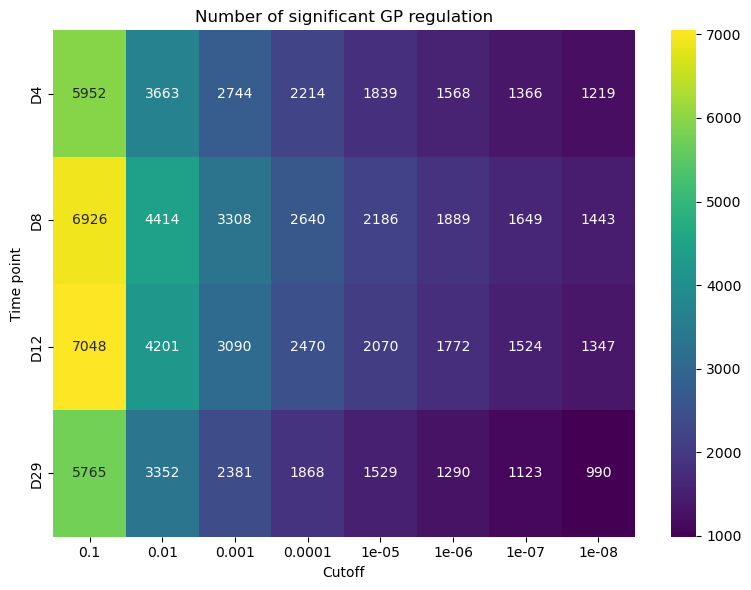

In [11]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    sig_pert_count_df,
    annot=True,
    fmt="d",
    cmap="viridis"
)

plt.title("Number of significant GP regulation")
plt.xlabel("Cutoff")
plt.ylabel("Time point")
plt.tight_layout()
plt.savefig("../figure/gp_reg_table.pdf")

plt.show()

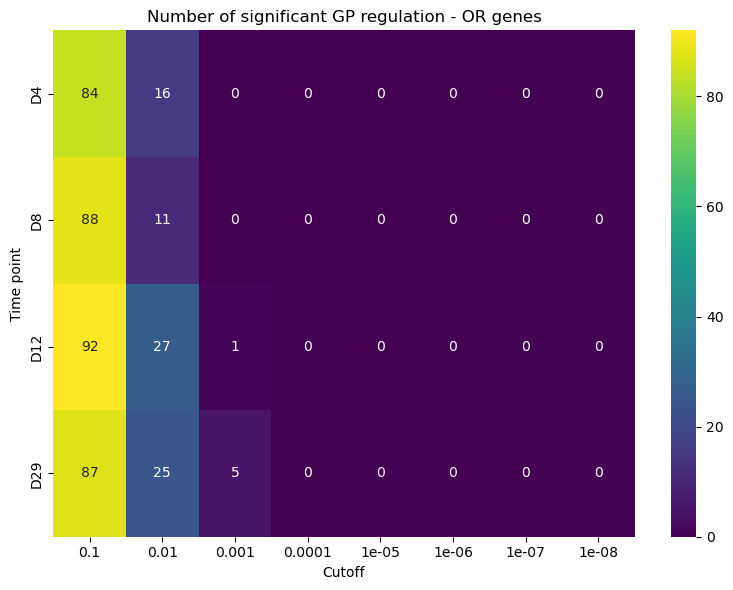

In [12]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    or_gene_overlap_count_df,
    annot=True,
    fmt="d",
    cmap="viridis"
)

plt.title("Number of significant GP regulation - OR genes")
plt.xlabel("Cutoff")
plt.ylabel("Time point")
plt.tight_layout()
plt.savefig("../figure/gp_reg_table_OR.pdf")

plt.show()

### Convert to the gene ID to standard symbol

In [13]:
genes = np.concatenate([item.values for key,item in top300_df_dict.items()])
genes = np.unique(genes)
genes = [g for g in genes if isinstance(g, str) and g.strip()]


In [14]:
# Query MyGene.info in batch
mg = mygene.MyGeneInfo()
hits = mg.querymany(
    genes,
    scopes="symbol,alias,ensembl.gene,entrezgene",
    fields="symbol,name,alias,ensembl.gene,entrezgene,taxid",
    species="human",
    as_dataframe=True,
    returnall=True
)

Input sequence provided is already in string format. No operation performed


Input sequence provided is already in string format. No operation performed


789 input query terms found dup hits:	[('A2ML1-AS1', 2), ('AADACL2-AS1', 3), ('ABHD15-AS1', 2), ('ACAT1', 2), ('ACAT2', 2), ('ACBD3-AS1', 


58 input query terms found no hit:	['ARMCX5-GPRASP2-1', 'AUXG01000058.1', 'CRIPAK', 'CYB561D2-1', 'GGT1-1', 'HSPA14-1', 'MATR3-1', 'TBC


In [15]:
top300_df_dict_normalized = {}

# Build a mapping table manually after reviewing ambiguous hits
mapping = (
    hits["out"]
    .dropna(subset=["symbol"])
    [["symbol", "entrezgene", "taxid"]]
    .rename(columns={"symbol": "approved_symbol"})
)
symbol_map = dict(zip(mapping.index, mapping["approved_symbol"]))

for key,item in top300_df_dict.items():
    norm_df = item.copy()
    gene_cols = [c for c in item.columns if c != "Unnamed: 0"]
    norm_df[gene_cols] = norm_df[gene_cols].apply(lambda col: col.map(lambda x: symbol_map.get(x, x)))
    top300_df_dict_normalized[key] = norm_df.copy()

In [16]:
top300_df_dict_normalized["D4"].head()

,1,2,3,4,5,6,7,8,9,10,...,91,92,93,94,95,96,97,98,99,100
0,MIF,SNHG7,GAPDH,ALDH1A2,NOP16,H1-0,FLNA,ZAP70,COL1A1,HSP90AA1,...,FAM151A,H1-2,CSRP3,SERPINE1,MT2A,S100A11P1,PLVAP,IFIT1,DHRS2,CCNA1
1,ELOB,EIF1,ALDOA,LIX1,NME1,MT-CO1,FASN,APCDD1L-DT,RALYL,HNRNPA2B1,...,TINAGL1,H2BC12,DES,ANXA1,MT1E,S100A16,ECSCR,IFIT3,DPEP3,KHDC1L
2,NDUFA13,KRT19,FKBP8,PDGFRA,GNL3,EEF2,SRRM2,GYPE,BAMBI,HSPA8,...,MLKL,H2BC11,S100A2,HMOX1,MT1X,S100A13,DLL4,HERC5,FTCD,SLC34A2
3,FAU,ZNF581,HMGA1,MAP1B,EXOSC5,TPT1,PRRC2A,GYPB,VIM,SFPQ,...,CNTNAP4,H4C8,COL12A1,SFTA1P,MT1G,CST1,RP1,IFIT2,DDX43,PLXNB3
4,ATP5ME,PPP1CC,EEF1A1,SMOC1,SNHG15,GDI2,NCOR2,ANGPT2,VCAN,ACTB,...,RFPL2,H2AC6,SFTA2,SPP1,MT1F,HNF4A-AS1,ADCY4,ISG15,TDRD12,PGLYRP4


In [17]:
top_gene_dict = {}
for key in time_point_list:
    for gp_name in top300_df_dict_normalized[key].columns:
        top_gene_dict[f"{key}_Usage{gp_name}"] = top300_df_dict_normalized[key].loc[:,gp_name].values

In [18]:
res_list = []
for key,gene_list in tqdm(top_gene_dict.items()):
    gene_list = gene_list[:top_n_compare]
    perturb_time_point = key.split("_")[0]
    for key_embryo,gene_list_embryo in top_genes_embryo_dict.items():
        embryo_time_point = key_embryo.split("_")[0]
        overlap_embryo_gp = set(gene_list_embryo) & set(gene_list)
        overlap_embryo_gp = list(overlap_embryo_gp)
        overlap_embryo_gp.sort()
        
        num_overlap_embryo_gp = len(overlap_embryo_gp)
        res_list.append([key,key_embryo,perturb_time_point,embryo_time_point,
                         num_overlap_embryo_gp, overlap_embryo_gp])

  0%|          | 0/400 [00:00<?, ?it/s]

  5%|▌         | 20/400 [00:00<00:01, 193.07it/s]

 10%|█         | 40/400 [00:00<00:01, 191.63it/s]

 15%|█▌        | 60/400 [00:00<00:01, 193.44it/s]

 20%|██        | 80/400 [00:00<00:01, 195.17it/s]

...

 85%|████████▍ | 339/400 [00:02<00:00, 181.23it/s]

 90%|████████▉ | 359/400 [00:02<00:00, 184.99it/s]

 95%|█████████▍| 379/400 [00:02<00:00, 185.73it/s]

100%|█████████▉| 398/400 [00:02<00:00, 126.20it/s]

100%|██████████| 400/400 [00:02<00:00, 159.05it/s]

In [19]:
res_list_df = pd.DataFrame(res_list,columns=["Time_Course_gp_name","Embryo_gp_name",
                                             "Perturb_time_point","Embryo_time_point",
                                             "Num_overlap_gene","overlapped_genes"
                                            ])

In [20]:
res_list_df["rank_in_time_course"] = \
    res_list_df.groupby("Time_Course_gp_name")["Num_overlap_gene"]\
               .rank(method="min", ascending=False).astype(int)

In [21]:
res_list_df

,Time_Course_gp_name,Embryo_gp_name,Perturb_time_point,Embryo_time_point,Num_overlap_gene,overlapped_genes,rank_in_time_course
0,D4_Usage1,CS8_Usage1,D4,CS8,1,[IFITM3],103
1,D4_Usage1,CS8_Usage2,D4,CS8,33,"[ANAPC11, ATP5ME, ATP5MF, ELOB, FTH1, GSTP1, M...",4
2,D4_Usage1,CS8_Usage3,D4,CS8,2,"[FTL, SERF2]",61
3,D4_Usage1,CS8_Usage4,D4,CS8,17,"[ATP5F1D, ATP5MC2, BEX3, FAU, FTH1, GSTP1, H3-...",8
4,D4_Usage1,CS8_Usage5,D4,CS8,3,"[IFITM3, MYL6, TMSB10]",48
...,...,...,...,...,...,...,...
199995,D29_Usage100,Embryo_heart_Usage96,D29,Embryo,0,[],201
199996,D29_Usage100,Embryo_heart_Usage97,D29,Embryo,2,"[APOC2, HPGD]",51
199997,D29_Usage100,Embryo_heart_Usage98,D29,Embryo,0,[],201
199998,D29_Usage100,Embryo_heart_Usage99,D29,Embryo,1,[UPK3A],95


In [22]:
#Select significantly overlapping GPs (cutoff=5), Save
res_list_df_sig = res_list_df[res_list_df["Num_overlap_gene"]>10].copy()
res_list_df_sig.to_csv("../processed_data/overlapping_gp_sig_time_course_merged.csv")

Text(0.5, 1.0, 'top100 genes overlap')

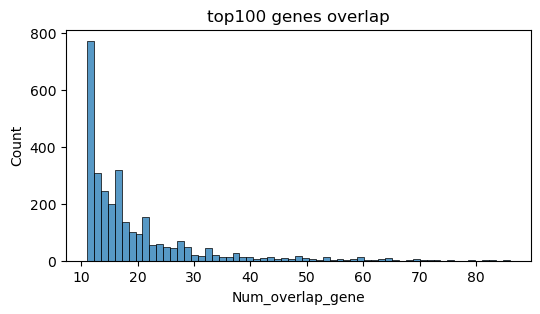

In [23]:
fig,ax = plt.subplots(figsize=(6,3))
sns.histplot(res_list_df_sig["Num_overlap_gene"],ax=ax)
ax.set_title("top100 genes overlap")

(26, 27)


(41, 45)


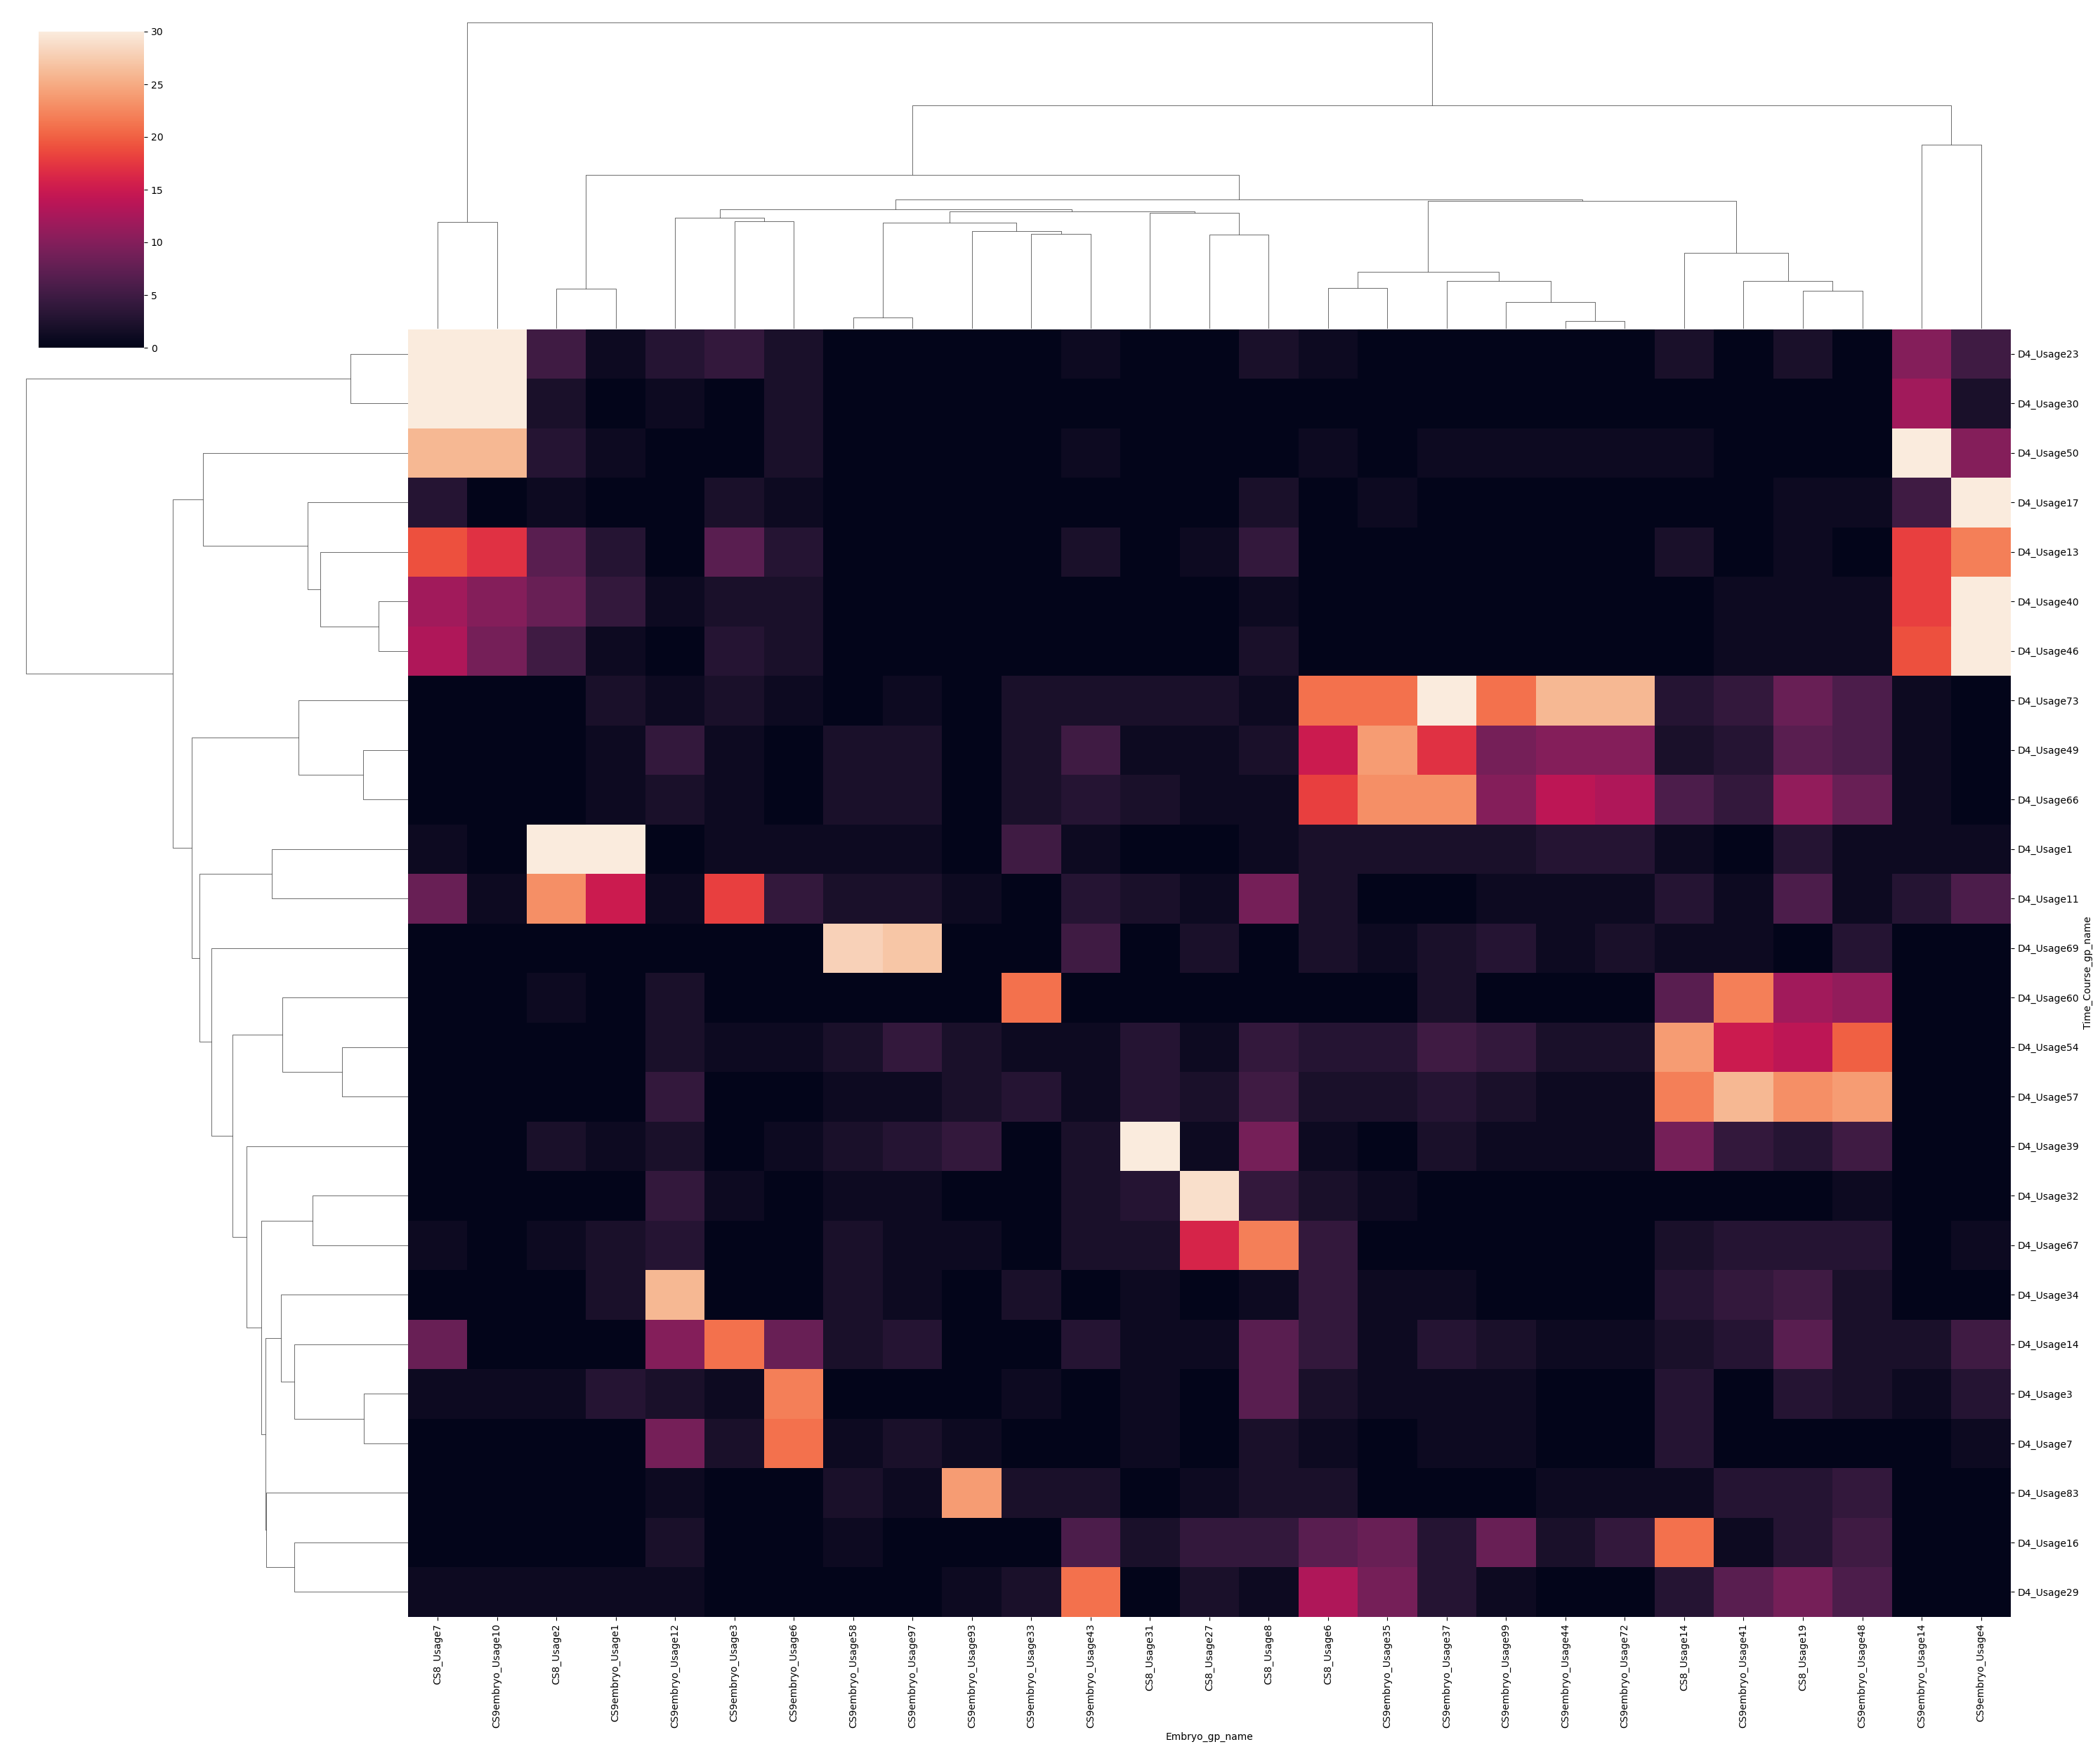

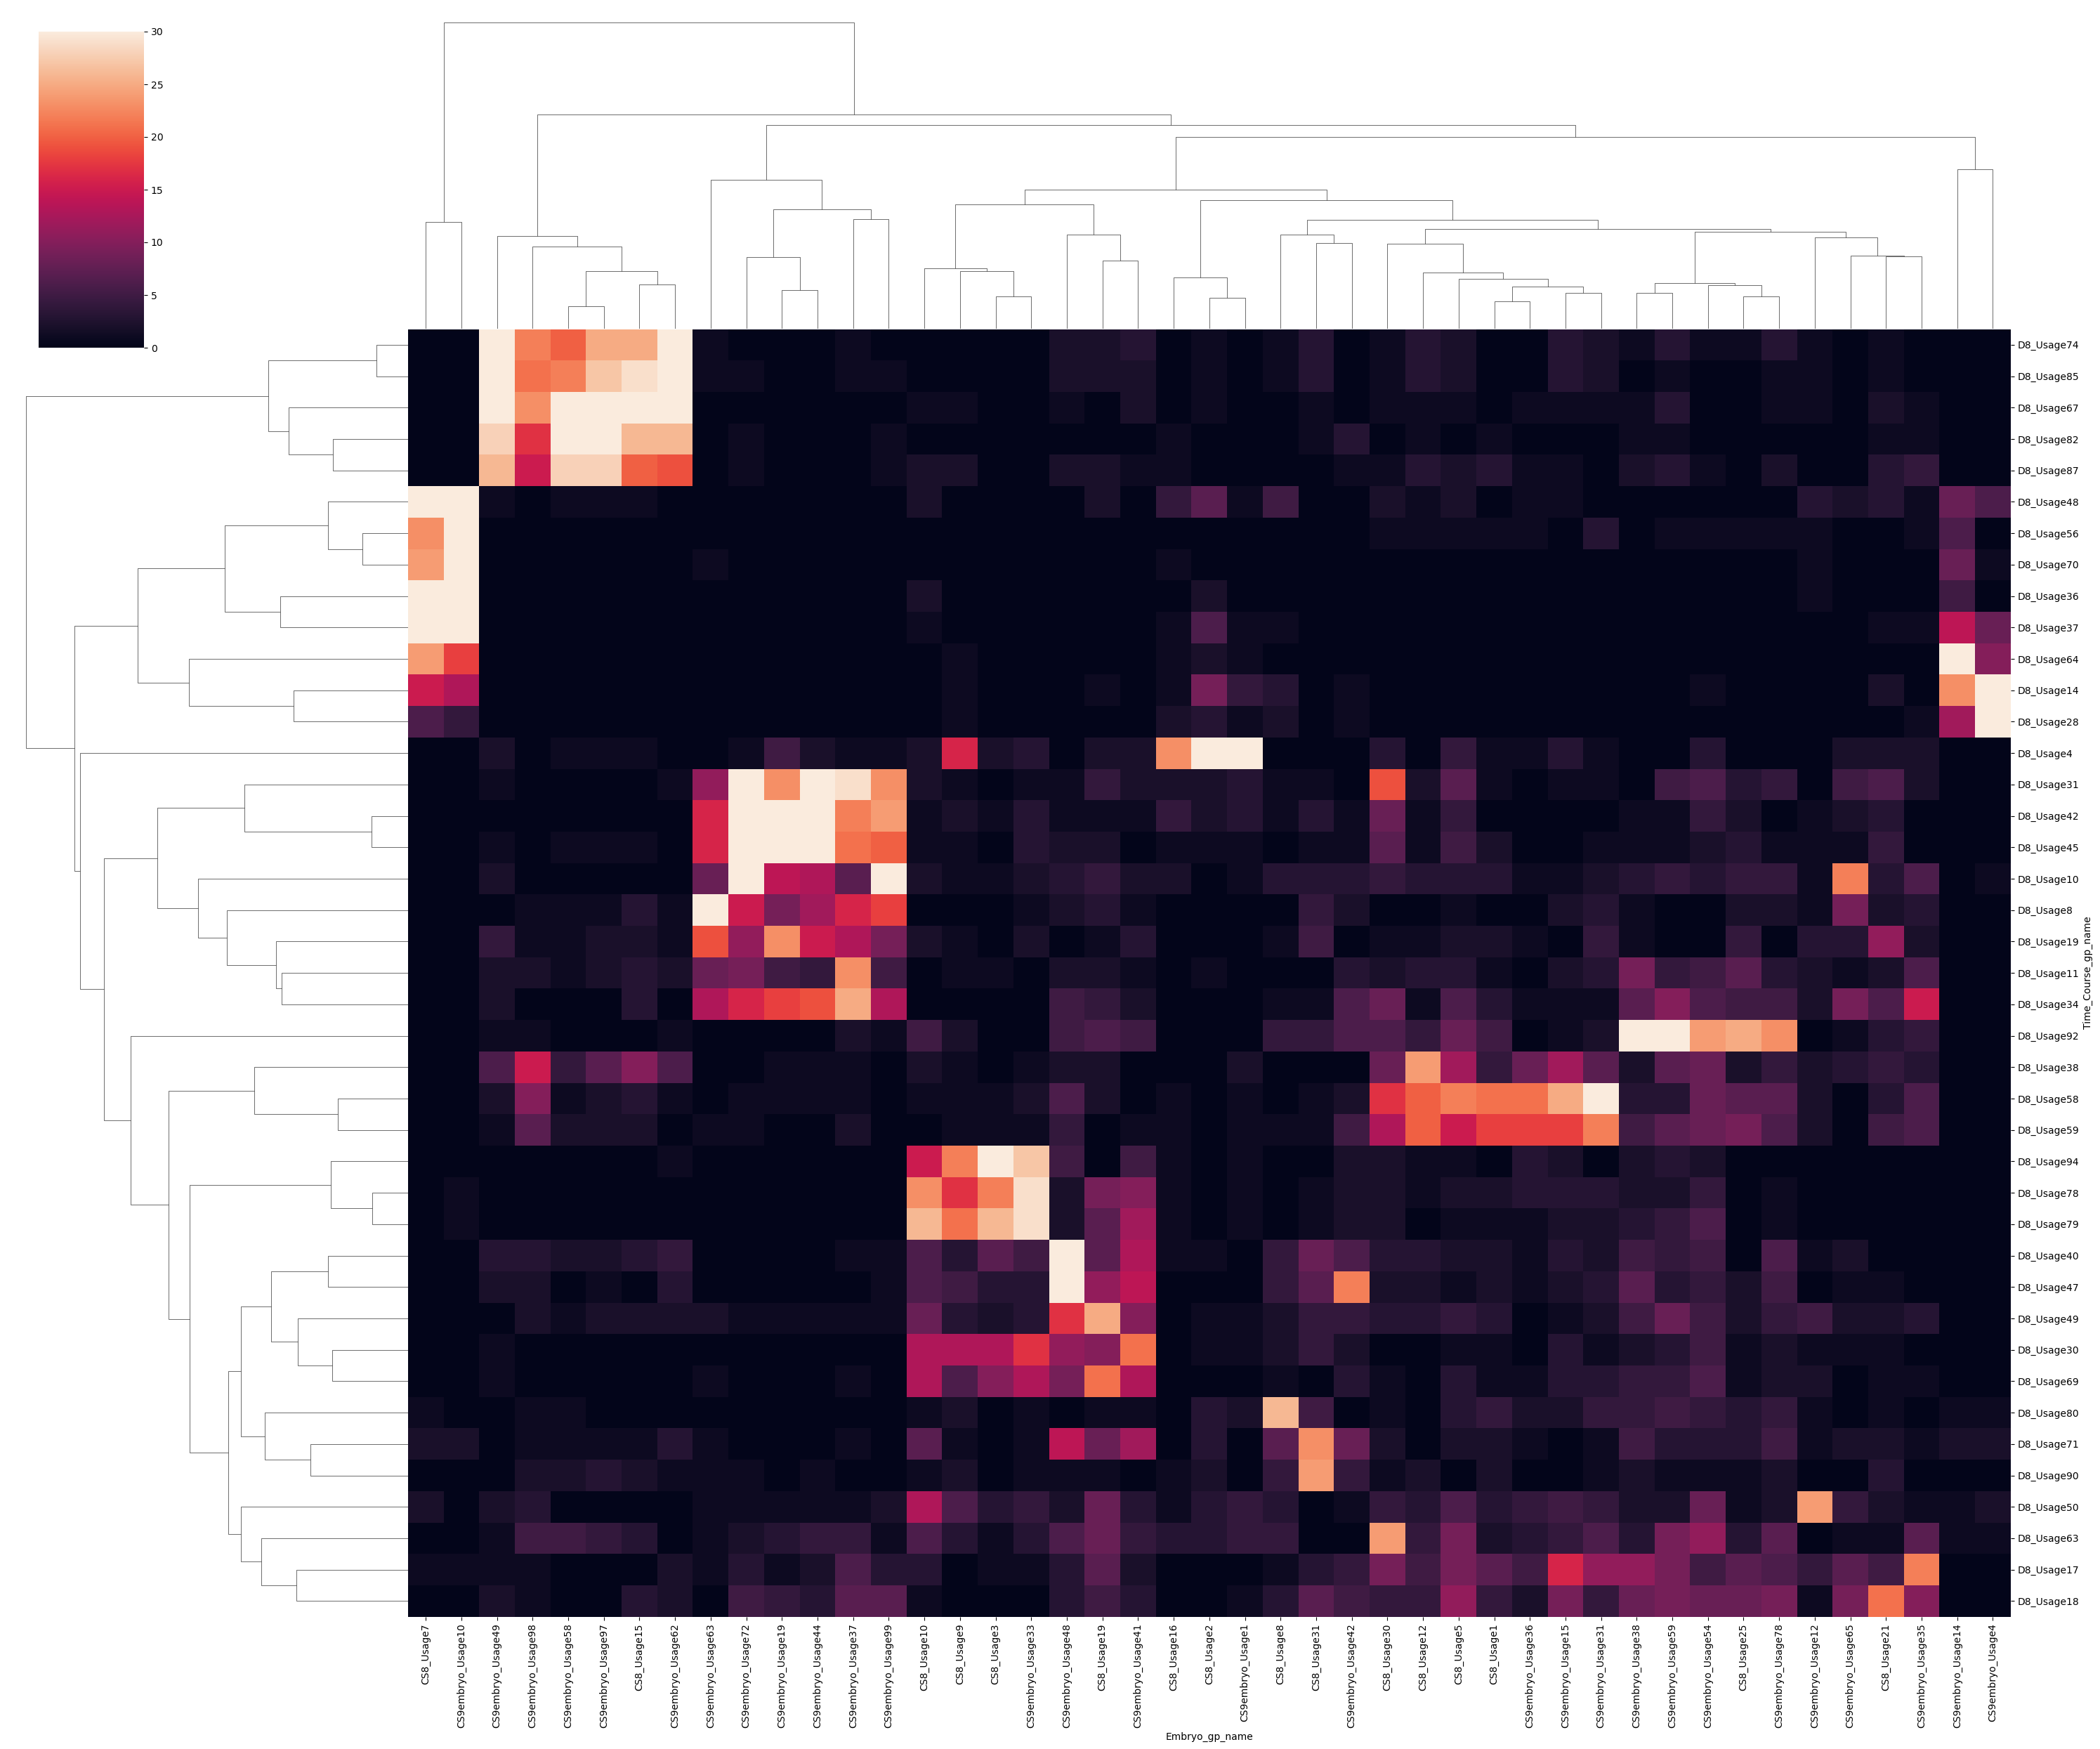

In [24]:
for time_point in ["D4","D8"]:
    res_list_df_CS89_pivot_tp = \
        res_list_df[((res_list_df["Embryo_time_point"] == "CS8") | \
                    (res_list_df["Embryo_time_point"] == "CS9embryo")) & \
                    (res_list_df["Perturb_time_point"] == time_point)
                   ].pivot(index="Time_Course_gp_name",columns="Embryo_gp_name",values="Num_overlap_gene")
    
    res_list_df_CS89_pivot_tp.to_csv(f"../processed_data/overlap_gp_CS89_pivot_{time_point}.csv")
    
    res_list_df_CS89_pivot_tp_sig = \
        res_list_df_CS89_pivot_tp.loc[
            res_list_df_CS89_pivot_tp.apply(lambda x:np.max(x)>20,axis=1),
            res_list_df_CS89_pivot_tp.apply(lambda x:np.max(x)>20,axis=0)
            ]
    print(res_list_df_CS89_pivot_tp_sig.shape)
    #Plot
    g = sns.clustermap(res_list_df_CS89_pivot_tp_sig,vmax=30,figsize=(30,25))
    g.savefig(f"../figure/clustermap_{time_point}_CS89_comparison.pdf")

### Visualize important GP overlapping with in vivo GPs

In [25]:
cell_type_annotation_dict

{'Epiblast': 'CS8_Usage8',
 'Cardiac mesoderm': 'CS8_Usage21',
 'Endoderm': 'CS8_Usage31',
 'FHF': 'CS9embryo_Usage65',
 'SHF': 'CS9embryo_Usage32'}

In [127]:
res_list = []

for cell_type_name,gp_name in cell_type_annotation_dict.items():
    res_list_df_ext = res_list_df[res_list_df["Embryo_gp_name"]==gp_name]

    for time_point in time_point_list:
        res_list_df_ext_time = res_list_df_ext[res_list_df_ext["Perturb_time_point"]==time_point]
        top_overlap = res_list_df_ext_time.sort_values("Num_overlap_gene",ascending=False).iloc[0]
        top_overlap_name = top_overlap["Time_Course_gp_name"]
        top_overlap_num = top_overlap["Num_overlap_gene"]
        res_list.append([cell_type_name,gp_name,top_overlap_name,top_overlap_num])
        print(cell_type_name,gp_name,top_overlap_name,top_overlap_num)

Epiblast CS8_Usage8 D4_Usage67 22
Epiblast CS8_Usage8 D8_Usage80 26
Epiblast CS8_Usage8 D12_Usage84 9
Epiblast CS8_Usage8 D29_Usage99 19
Cardiac mesoderm CS8_Usage21 D4_Usage64 20
Cardiac mesoderm CS8_Usage21 D8_Usage18 21
Cardiac mesoderm CS8_Usage21 D12_Usage37 14
Cardiac mesoderm CS8_Usage21 D29_Usage33 11
Endoderm CS8_Usage31 D4_Usage39 31
Endoderm CS8_Usage31 D8_Usage90 24
Endoderm CS8_Usage31 D12_Usage84 14
Endoderm CS8_Usage31 D29_Usage99 9
FHF CS9embryo_Usage65 D4_Usage73 10
FHF CS9embryo_Usage65 D8_Usage10 22
FHF CS9embryo_Usage65 D12_Usage51 19
FHF CS9embryo_Usage65 D29_Usage21 16
SHF CS9embryo_Usage32 D4_Usage4 18
SHF CS9embryo_Usage32 D8_Usage32 12
SHF CS9embryo_Usage32 D12_Usage40 8
SHF CS9embryo_Usage32 D29_Usage78 10


In [128]:
'''
Epiblast CS8_Usage8 D4_Usage67 70
Primitive streak CS8_Usage29 D4_Usage10 61

Cardiac mesoderm CS8_Usage21 D4_Usage49 73
FHF CS9_Usage59 D8_Usage10 123
SHF CS9_Usage45 D8_Usage32 41
Endoderm CS8_Usage31 D4_Usage39 88
'''

'\nEpiblast CS8_Usage8 D4_Usage67 70\nPrimitive streak CS8_Usage29 D4_Usage10 61\n\nCardiac mesoderm CS8_Usage21 D4_Usage49 73\nFHF CS9_Usage59 D8_Usage10 123\nSHF CS9_Usage45 D8_Usage32 41\nEndoderm CS8_Usage31 D4_Usage39 88\n'

In [129]:
closest_gp_df = pd.DataFrame(res_list,columns=["cell_type","vivo_program","time_course_program","num_overlap"])
closest_gp_df["time_course"] = closest_gp_df["time_course_program"].apply(lambda x:x.split("_")[0])

In [130]:
closest_gp_df[closest_gp_df["time_course"]=="D4"]

,cell_type,vivo_program,time_course_program,num_overlap,time_course
0,Epiblast,CS8_Usage8,D4_Usage67,22,D4
4,Cardiac mesoderm,CS8_Usage21,D4_Usage64,20,D4
8,Endoderm,CS8_Usage31,D4_Usage39,31,D4
12,FHF,CS9embryo_Usage65,D4_Usage73,10,D4
16,SHF,CS9embryo_Usage32,D4_Usage4,18,D4


In [131]:
important_gp_list = list(cell_type_annotation_dict.values())
important_time_course_gp_list = ["D4_Usage67","D4_Usage39","D4_Usage64",
                                 "D8_Usage10","D8_Usage32"]

In [132]:
important_gp_table = res_list_df.loc[(np.isin(res_list_df["Embryo_gp_name"].values,important_gp_list)) & \
                                     (np.isin(res_list_df["Time_Course_gp_name"].values,important_time_course_gp_list))]

In [133]:
important_gp_table_pivot = \
    important_gp_table.pivot(index="Time_Course_gp_name",
                             columns="Embryo_gp_name",
                             values="Num_overlap_gene")

In [134]:
col_new = important_gp_table_pivot.columns.to_list()
for key,gp_name in cell_type_annotation_dict.items():
    idx = np.where(important_gp_table_pivot.columns==gp_name)[0][0]
    col_new[idx] = key
important_gp_table_pivot.columns=col_new

In [135]:
important_gp_table_pivot = important_gp_table_pivot.loc[important_time_course_gp_list,
                                ["Epiblast","Endoderm","Cardiac mesoderm","FHF","SHF"]]

In [136]:
important_gp_table_pivot.sort_values("SHF")

,Epiblast,Endoderm,Cardiac mesoderm,FHF,SHF
Time_Course_gp_name,,,,,
D4_Usage67,22,2,0,0,0
D4_Usage39,9,31,1,2,1
D8_Usage10,3,3,3,22,1
D4_Usage64,1,4,20,4,5
D8_Usage32,2,3,6,4,12


In [137]:
# Epiblast: D4_Usage67
# Endoderm: D4_Usage39
# Cardiac/LP mesoderm: D4_Usage49
# FHF: D8_Usage10
# SHF/Endothelial: D8_Usage32

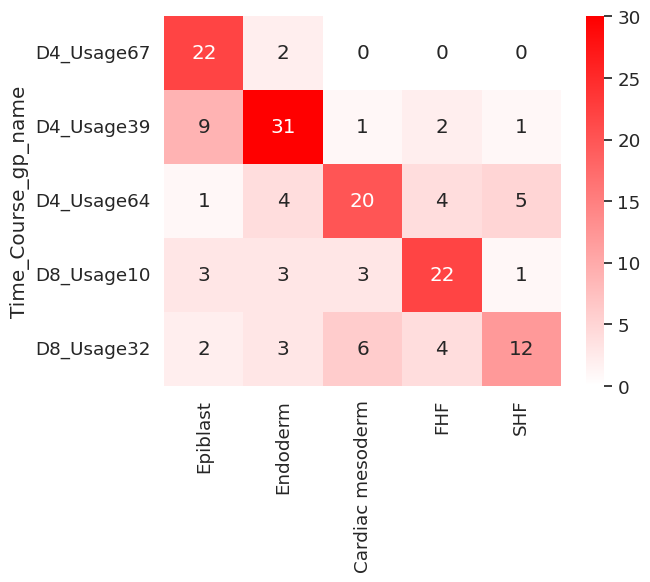

In [138]:
fig,ax=plt.subplots()
my_cmap = sns.blend_palette(["white", "red"], as_cmap=True)
sns.heatmap(important_gp_table_pivot,
            vmax=30,
            annot=True,
            cmap=my_cmap,
            ax=ax)
plt.savefig("../figure/gp_overlap.pdf")

In [139]:
marker_genes_dict={
    "Epiblast":["SOX2","POU5F1"],
    "Endoderm": ["SOX17","CER1"],
    "Cardiac mesoderm": ["MYL7","HAPLN1"],
    "FHF":["TBX5","HCN4","NKX2-5","TNNT2"],
    "SHF":["ISL1","TBX1","LMO2","ANGPT2"],
}

#### Marker Gene: Time-course

In [140]:
res_list = []
for gp_name in important_gp_table_pivot.index:
    for cell_type, marker_genes in marker_genes_dict.items():
        for cell_type_gene in marker_genes:
            if cell_type_gene in top_gene_dict[gp_name]:
                gene_rank = np.where(top_gene_dict[gp_name]==cell_type_gene)[0][0]+1
            else:
                gene_rank = np.nan
            res_list.append([gp_name,cell_type,cell_type_gene,gene_rank])

marker_gene_df = pd.DataFrame(res_list,columns=["GP_name","cell_type","Marker_gene","rank"])

In [141]:
important_time_course_gp_list

['D4_Usage67', 'D4_Usage39', 'D4_Usage64', 'D8_Usage10', 'D8_Usage32']

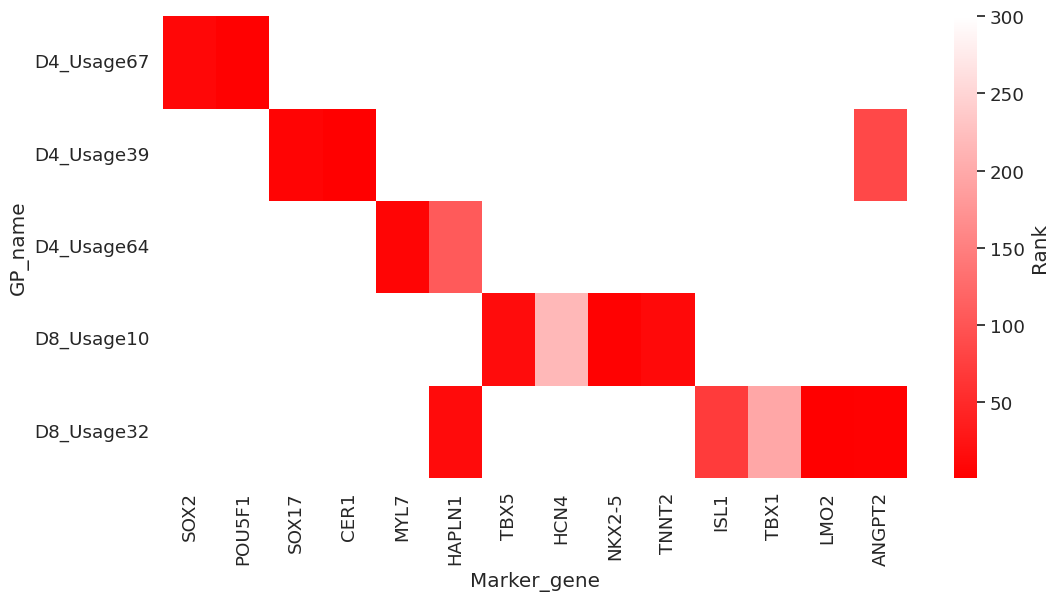

In [142]:
marker_gene_df_pivot = marker_gene_df.pivot(index="GP_name",columns="Marker_gene",values="rank")
marker_gene_df_pivot = marker_gene_df_pivot.fillna(300)
col_name = np.concatenate(list(marker_genes_dict.values()))

marker_gene_df_pivot = marker_gene_df_pivot.loc[important_gp_table_pivot.index.tolist(),col_name]
cmap = sns.blend_palette(["red", "white"], as_cmap=True)

sns.set_theme(style="white", font_scale=1.2)

plt.figure(figsize=(12, 6))
ax = sns.heatmap(
    marker_gene_df_pivot,
    cmap=cmap,
    vmin=1,
    vmax=300,
    linewidths=0.0,
    linecolor="white",
    cbar_kws={"label": "Rank"}
)
plt.savefig("../figure/gene_marker_time_course.pdf")

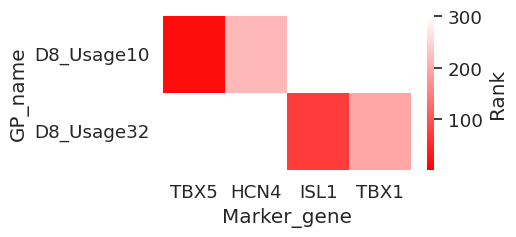

In [143]:
#Focused plot on FHF/SHF

marker_gene_df_pivot = marker_gene_df.pivot(index="GP_name",columns="Marker_gene",values="rank")
marker_gene_df_pivot = marker_gene_df_pivot.fillna(300)

row_name = ["D8_Usage10","D8_Usage32"]
col_name = ["TBX5","HCN4","ISL1","TBX1"]

marker_gene_df_pivot_select = marker_gene_df_pivot.loc[row_name,col_name]
cmap = sns.blend_palette(["red", "white"], as_cmap=True)

sns.set_theme(style="white", font_scale=1.2)

plt.figure(figsize=(4, 2))
ax = sns.heatmap(
    marker_gene_df_pivot_select,
    cmap=cmap,
    vmin=1,
    vmax=300,
    linewidths=0.0,
    linecolor="white",
    cbar_kws={"label": "Rank"}
)
plt.savefig("../figure/gene_marker_time_course_select.pdf")

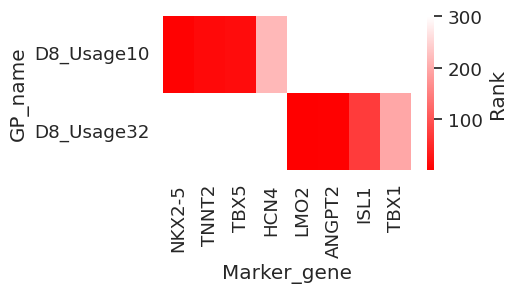

In [144]:
#Focused plot on FHF/SHF

marker_gene_df_pivot = marker_gene_df.pivot(index="GP_name",columns="Marker_gene",values="rank")
marker_gene_df_pivot = marker_gene_df_pivot.fillna(300)

row_name = ["D8_Usage10","D8_Usage32"]
col_name = ["NKX2-5","TNNT2","TBX5","HCN4","LMO2","ANGPT2","ISL1","TBX1"]

marker_gene_df_pivot_select = marker_gene_df_pivot.loc[row_name,col_name]
cmap = sns.blend_palette(["red", "white"], as_cmap=True)

sns.set_theme(style="white", font_scale=1.2)

plt.figure(figsize=(4, 2))
ax = sns.heatmap(
    marker_gene_df_pivot_select,
    cmap=cmap,
    vmin=1,
    vmax=300,
    linewidths=0.0,
    linecolor="white",
    cbar_kws={"label": "Rank"}
)
plt.savefig("../figure/gene_marker_time_course_select2.pdf")

#### Marker Gene: In vivo

In [44]:
res_list = []
for gp_name in cell_type_annotation_dict.values():
    for cell_type, marker_genes in marker_genes_dict.items():
        for cell_type_gene in marker_genes:
            if cell_type_gene in top_genes_embryo_dict[gp_name]:
                gene_rank = np.where(top_genes_embryo_dict[gp_name]==cell_type_gene)[0][0]+1
            else:
                gene_rank = np.nan
            res_list.append([gp_name,cell_type,cell_type_gene,gene_rank])

marker_gene_vivo_df = pd.DataFrame(res_list,columns=["GP_name","cell_type","Marker_gene","rank"])

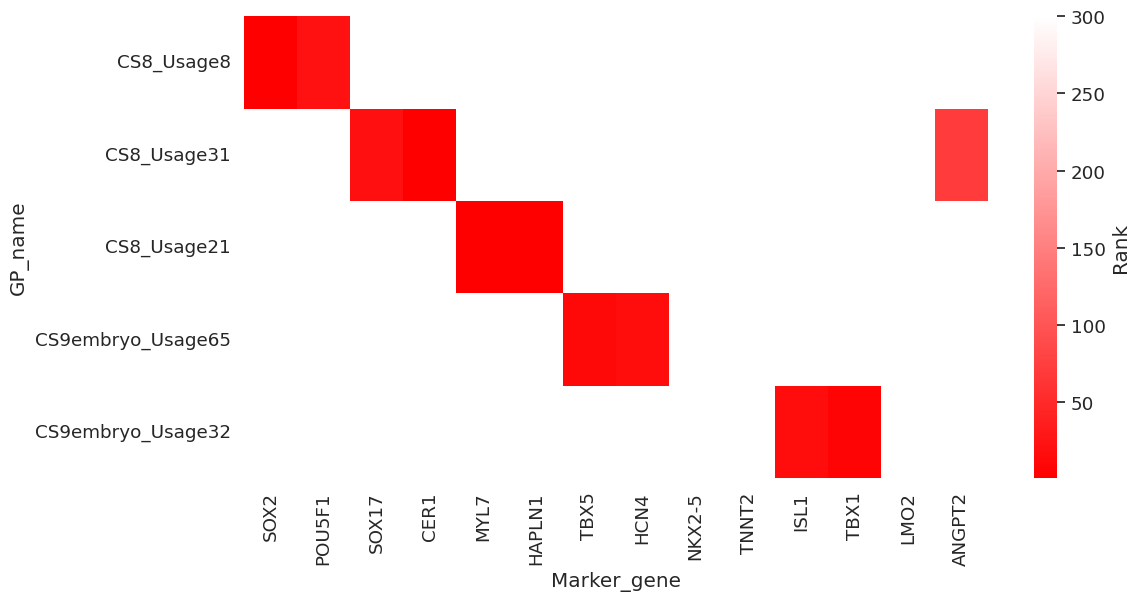

In [45]:
marker_gene_vivo_df_pivot = marker_gene_vivo_df.pivot(index="GP_name",columns="Marker_gene",values="rank")
marker_gene_vivo_df_pivot = marker_gene_vivo_df_pivot.fillna(300)

col_name = np.concatenate(list(marker_genes_dict.values()))
row_name = ["CS8_Usage8","CS8_Usage31","CS8_Usage21","CS9embryo_Usage65","CS9embryo_Usage32"]
marker_gene_vivo_df_pivot = marker_gene_vivo_df_pivot.loc[row_name,col_name]
cmap = sns.blend_palette(["red", "white"], as_cmap=True)

sns.set_theme(style="white", font_scale=1.2)

plt.figure(figsize=(12, 6))
ax = sns.heatmap(
    marker_gene_vivo_df_pivot,
    cmap=cmap,
    vmin=1,
    vmax=300,
    linewidths=0.0,
    linecolor="white",
    cbar_kws={"label": "Rank"}
)

plt.savefig("../figure/gene_marker_vivo.pdf")

### visualize regulator of Gene program

In [46]:
G = nx.DiGraph()

pos = {
    "Epiblast":(2,5),
    "Endoderm":(3,4),
    "Cardiac Mesoderm":(2,4),
    "FHF":(1.5,3),
    "SHF":(2.5,3),
}
edge_list = [("Epiblast","Endoderm"),
             ("Epiblast","Cardiac Mesoderm"),
             ("Cardiac Mesoderm","FHF"),
             ("Cardiac Mesoderm","SHF")
            ]

G.add_nodes_from(pos.keys(),fc=0.0)
G.add_edges_from(edge_list)

In [47]:
G.nodes

NodeView(('Epiblast', 'Endoderm', 'Cardiac Mesoderm', 'FHF', 'SHF'))

In [48]:
def draw_diff_graph(G_tmp: nx.DiGraph, pos: dict, return_fig=False):
    # --- 1. Visualization Setup ---
    fig, ax = plt.subplots(figsize=(12, 9), dpi=300)
    
    # --- 2. Draw Nodes with Dynamic Logic ---
    for node, (x, y) in pos.items():
        # Get 'fc' attribute for the node (default to 0 if not present)
        fc = G_tmp.nodes[node].get('fc', 0)
        
        # Color logic: Red (>0), Blue (<0), White (==0)
        if fc > 0:
            node_fc = "#FFCCCC"  # Light Red fill
            node_ec = "red"      # Red edge
        elif fc < 0:
            node_fc = "#CCCCFF"  # Light Blue fill
            node_ec = "blue"     # Blue edge
        else:
            node_fc = "#FFFFFF"  # White fill
            node_ec = "#333333"  # Dark Gray edge
            
        # Thickness logic: Base 1.5 + magnitude scaling
        node_lw = 1.5 + abs(fc) * 2.5
        
        # Apply dynamic style to bbox
        bbox_style = dict(
            boxstyle="round,pad=0.5",
            fc=node_fc,
            ec=node_ec,
            lw=node_lw
        )
        
        display_name = str(node).replace(" ", "\n")
        ax.text(x, y, display_name, 
                ha='center', va='center', 
                fontsize=10, fontweight='bold', 
                fontfamily='sans-serif',
                bbox=bbox_style, zorder=3)
    
    # --- 3. Draw Edges (Neutral Style) ---
    for start, end in G_tmp.edges():
        # Edges are now drawn with a consistent neutral style
        dynamic_arrow_style = dict(
            arrowstyle="-|>,head_length=0.6,head_width=0.3",
            connectionstyle="arc3,rad=0.15", 
            color="#888888", 
            lw=1.5
        )
        
        ax.annotate("",
                    xy=pos[end], xycoords='data',
                    xytext=pos[start], textcoords='data',
                    arrowprops=dict(**dynamic_arrow_style, 
                                    shrinkA=30, # Adjusted for node size
                                    shrinkB=30),
                    zorder=1,
                    alpha=0.5)
    
    # --- 4. Legend Setup ---
    # Legend for Node Colors
    color_legend_elements = [
        Patch(facecolor='#FFCCCC', edgecolor='red', label='fc > 0 (Up)'),
        Patch(facecolor='#CCCCFF', edgecolor='blue', label='fc < 0 (Down)'),
        Patch(facecolor='#FFFFFF', edgecolor='#333333', label='fc = 0 (Neutral)')
    ]
    
    # Legend for Border Thickness (using Line2D to represent lw)
    thickness_legend_elements = [
        Line2D([0], [0], color='#333333', lw=1.5, label='|fc| = 0'),
        Line2D([0], [0], color='#333333', lw=4.0, label='|fc| = 1'),
        Line2D([0], [0], color='#333333', lw=6.5, label='|fc| = 2')
    ]
    
    color_legend = ax.legend(handles=color_legend_elements, loc='upper left', 
                             title="Node State (fc)", framealpha=0.9)
    ax.add_artist(color_legend) 
    
    ax.legend(handles=thickness_legend_elements, loc='lower left', 
              title="Border Thickness", framealpha=0.9)

    # --- 5. Final Adjustments ---
    all_x = [p[0] for p in pos.values()]
    all_y = [p[1] for p in pos.values()]
    ax.set_xlim(min(all_x) - 1.0, max(all_x) + 1.0)
    ax.set_ylim(min(all_y) - 0.8, max(all_y) + 0.8)
    
    ax.axis('off')
    plt.title("Cell Lineage Map (Node-wise Difference)", 
              fontsize=14, pad=20, fontweight='bold')
    plt.tight_layout()
    
    if return_fig:
        return fig
    else:
        plt.show()

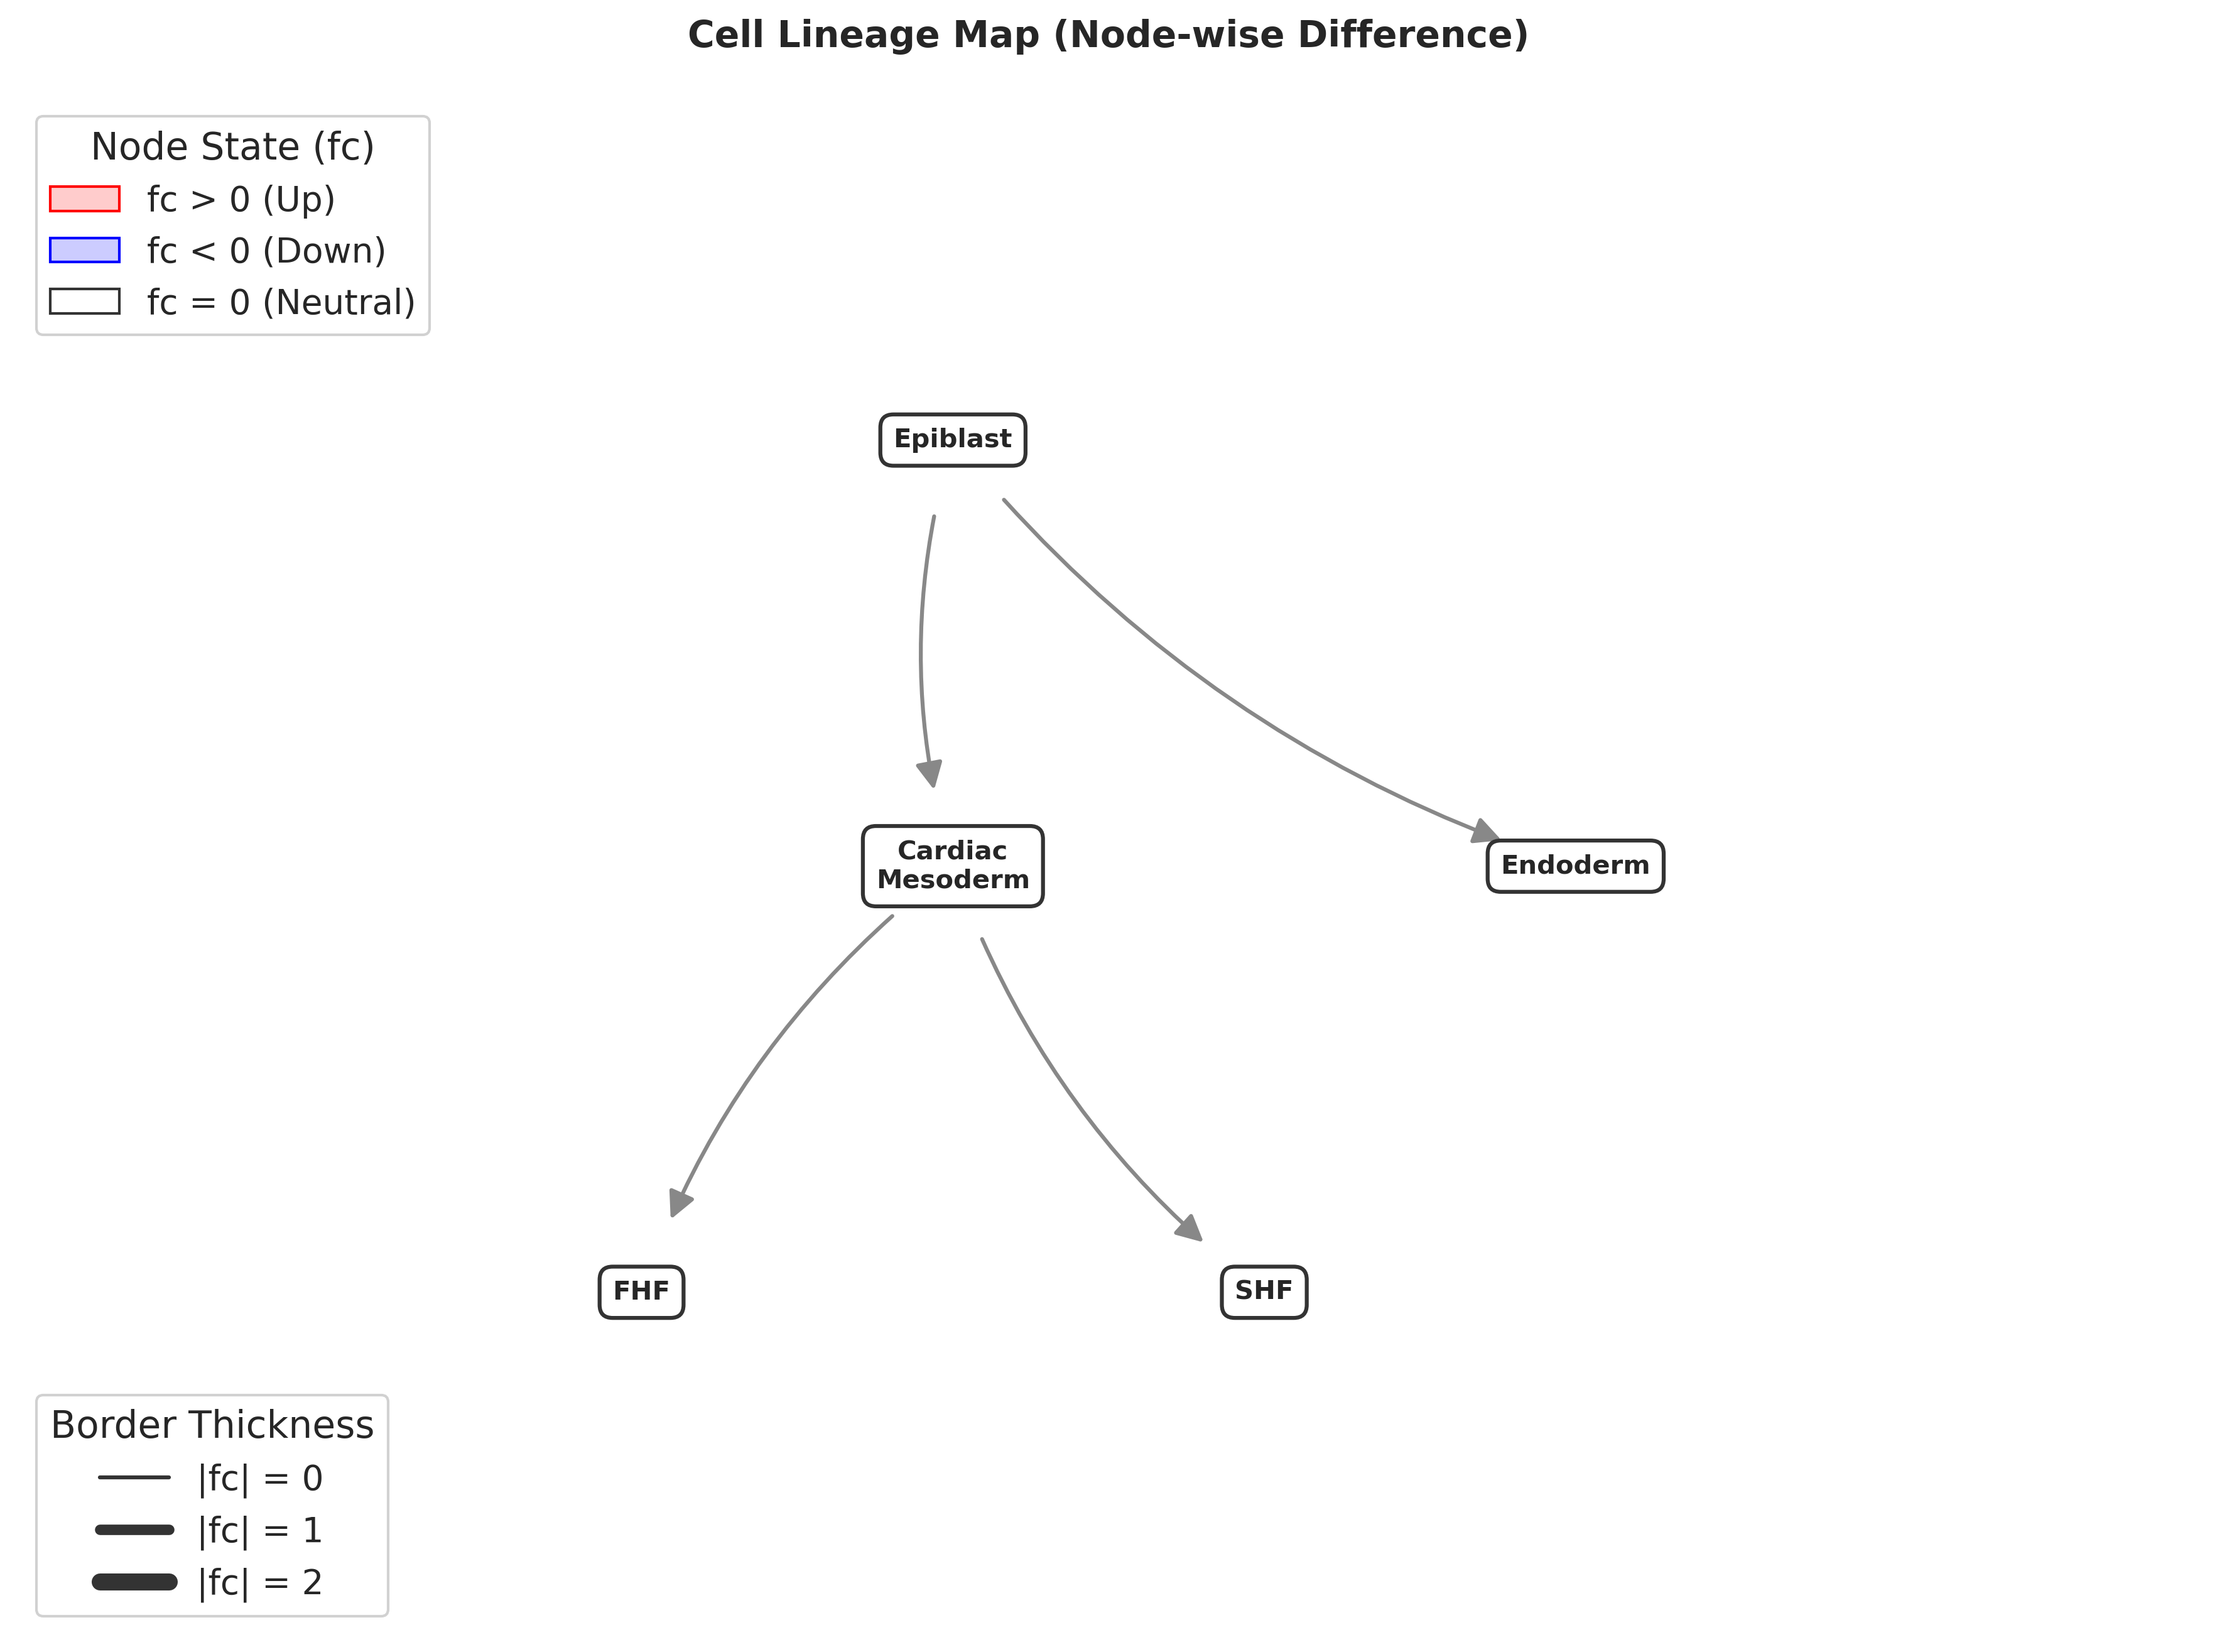

In [49]:
draw_diff_graph(G,pos)

In [50]:
#Usage based on CS8/CS9 data
gp_node_annotation = {
    "D4_Usage67": ("Epiblast"),
    "D4_Usage39": ("Endoderm"),
    "D4_Usage22": ("Cardiac Mesoderm"),
    "D8_Usage10": ("FHF"),
    "D8_Usage32": ("SHF")
}

regulation_df_dict_total.keys()
pert_name_list = regulation_df_dict_total["D4"]["Gene"].unique()

In [51]:
regulation_df_dict_total_merge

,Gene,Score Column,Statistic,p-value,Log2 Fold Change,Corrected p-value (BH),dataset,time_point
0,non-targeting (self),D4_Usage1,473488764.5,1.000000e+00,NaN,1.000000e+00,usage_norm_k_100,D4
1,ADNP2:P1P2,D4_Usage1,23736728.5,1.180699e-08,-0.143098,3.093465e-07,usage_norm_k_100,D4
2,AFF4:P1P2,D4_Usage1,28809202.0,8.878805e-01,0.012576,9.718723e-01,usage_norm_k_100,D4
3,AHCY:P1P2,D4_Usage1,28643010.5,7.975510e-01,-0.014176,9.413103e-01,usage_norm_k_100,D4
4,AHDC1:P1P2,D4_Usage1,20633495.5,8.523650e-01,-0.002299,9.616283e-01,usage_norm_k_100,D4
...,...,...,...,...,...,...,...,...
38595,ZNF8:P1P2,D29_Usage100,17665767.5,7.202165e-01,0.023466,9.015844e-01,usage_norm_k_100,D29
38596,ZNF91:P1P2,D29_Usage100,18908247.5,9.038940e-01,-0.550621,9.718778e-01,usage_norm_k_100,D29
38597,ZSCAN10:P1P2,D29_Usage100,11068831.0,2.405324e-01,-0.811801,5.741170e-01,usage_norm_k_100,D29
38598,ZSCAN20:P1P2,D29_Usage100,9777129.0,2.459087e-01,0.027306,5.787498e-01,usage_norm_k_100,D29


In [52]:
reg_df_stat_log2fc = regulation_df_dict_total_merge[
                        (regulation_df_dict_total_merge["Score Column"].apply(lambda x: x in gp_node_annotation.keys()))
                    ].pivot(columns="Score Column",values="Log2 Fold Change",index="Gene")
reg_df_stat_fdr = regulation_df_dict_total_merge[
                        (regulation_df_dict_total_merge["Score Column"].apply(lambda x: x in gp_node_annotation.keys()))
                    ].pivot(columns="Score Column",values="Corrected p-value (BH)",index="Gene")

In [53]:
fdr_cutoff = 1E-4
reg_df_stat_log2fc_sig = reg_df_stat_log2fc[reg_df_stat_fdr<fdr_cutoff]

In [54]:
reg_df_stat_log2fc_sig = reg_df_stat_log2fc_sig.dropna(axis=0,how="all").fillna(0)

In [55]:
reg_df_stat_log2fc_sig.columns = reg_df_stat_log2fc_sig.columns.map(gp_node_annotation)

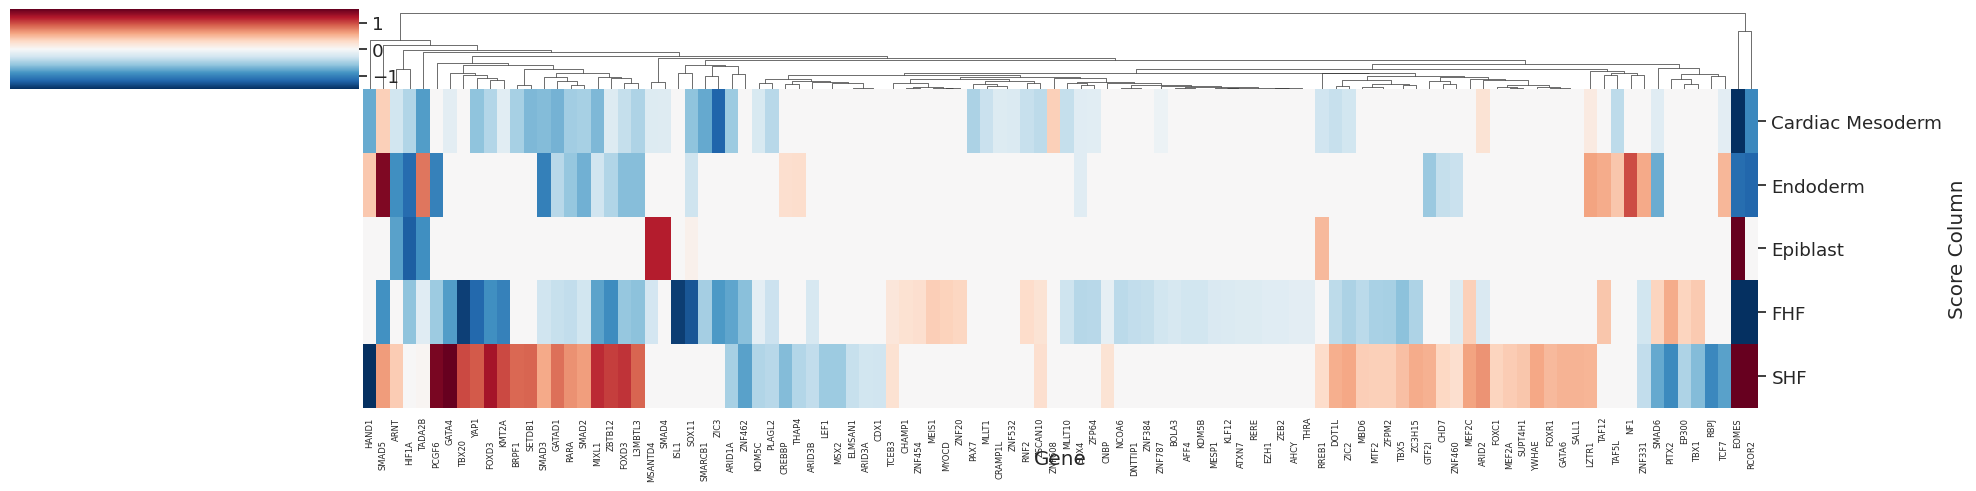

In [56]:
g = sns.clustermap(reg_df_stat_log2fc_sig.T,cmap="RdBu_r",row_cluster=False,
               vmax=1.5,vmin=-1.5,figsize=(20,6))
ax = g.ax_heatmap

# Use all labels in clustered order
labels = g.data2d.columns
xpos = np.arange(len(labels)) + 0.5

# Remove default tick labels
ax.set_xticks([])
ax.tick_params(axis="x", length=0)

# Draw all labels manually in two rows
for i, (x, lab) in enumerate(zip(xpos, labels)):
    lab=lab.split(":")[0]
    y = -0.03 if i % 2 == 0 else -0.10
    ax.text(
        x, y, lab,
        rotation=90,
        ha="center",
        va="top",
        fontsize=6,
        transform=ax.get_xaxis_transform(),
        clip_on=False
    )

ax.set_xlabel("Gene", labelpad=30)
g.fig.subplots_adjust(bottom=0.30)
g.savefig("../figure/clustermap.pdf", dpi=300)

In [57]:
reg_df_stat_log2fc_sig.to_csv("../processed_data/gp_regulation_cm_anno.csv")

In [58]:
reg_df_stat_log2fc.head()

Score Column,D4_Usage22,D4_Usage39,D4_Usage67,D8_Usage10,D8_Usage32
Gene,,,,,
ADNP2:P1P2,-0.174049,-0.203183,0.117571,0.082546,-0.096516
AFF4:P1P2,-0.072698,-0.043862,0.531015,-0.281637,0.181968
AHCY:P1P2,-0.045694,-0.143415,-0.008702,-0.163931,0.152928
AHDC1:P1P2,-0.164826,-0.182217,-0.079584,-0.062727,-0.079654
APITD1:P1P2,-0.026473,0.424563,0.531909,-0.115107,-0.220367


In [59]:
reg_df_stat_fdr.head()

Score Column,D4_Usage22,D4_Usage39,D4_Usage67,D8_Usage10,D8_Usage32
Gene,,,,,
ADNP2:P1P2,0.002875,0.308138,0.927520,5.854419e-01,0.929219
AFF4:P1P2,0.047547,0.206269,0.933644,5.929980e-08,0.001913
AHCY:P1P2,0.662486,0.379493,0.978244,9.341618e-05,0.081869
AHDC1:P1P2,0.008364,0.396935,0.675752,2.945716e-01,0.677369
APITD1:P1P2,0.713985,0.005297,0.426781,2.353408e-03,0.000111


In [60]:
reg_df_stat_fdr.loc["ISL1:P1"]

Score Column
D4_Usage22    3.080357e-01
D4_Usage39    9.224000e-01
D4_Usage67    3.629089e-01
D8_Usage10    4.500376e-60
D8_Usage32    2.118875e-04
Name: ISL1:P1, dtype: float64

In [61]:
reg_df_stat_fdr.loc["TBX1:P1P2"]

Score Column
D4_Usage22    6.987922e-01
D4_Usage39    8.467553e-01
D4_Usage67    5.916603e-01
D8_Usage10    7.482310e-07
D8_Usage32    9.932875e-08
Name: TBX1:P1P2, dtype: float64

In [62]:
annotated_graph_dict = {}

for pert_name in pert_name_list:
    G_pert = G.copy()
    for gp_name, node_anno in gp_node_annotation.items():
        if reg_df_stat_fdr.at[pert_name,gp_name] < fdr_cutoff:
            G_pert.nodes()[node_anno]["fc"] = reg_df_stat_log2fc.at[pert_name,gp_name]
        else:
            G_pert.nodes()[node_anno]["fc"] = 0
    annotated_graph_dict[pert_name] = G_pert

In [63]:
with PdfPages('../figure/lineage_gp_regulation_stereo.pdf') as pdf:
    for key in tqdm(annotated_graph_dict.keys()):
        fig = draw_diff_graph(annotated_graph_dict[key],pos,return_fig=True)
        plt.title(key)
        pdf.savefig(fig)
        plt.close()

  0%|          | 0/382 [00:00<?, ?it/s]

  0%|          | 1/382 [00:00<00:47,  8.08it/s]

  1%|          | 3/382 [00:00<00:37, 10.15it/s]

  1%|▏         | 5/382 [00:00<00:35, 10.70it/s]

  2%|▏         | 7/382 [00:00<00:34, 10.94it/s]

...

 98%|█████████▊| 375/382 [00:35<00:00, 11.14it/s]

 99%|█████████▊| 377/382 [00:36<00:00, 11.15it/s]

 99%|█████████▉| 379/382 [00:36<00:00, 11.14it/s]

100%|█████████▉| 381/382 [00:36<00:00, 11.14it/s]

100%|██████████| 382/382 [00:36<00:00, 10.46it/s]

### Focus on FHF/SHF differentiation

In [64]:
reg_df_stat_fhf_shf = reg_df_stat_log2fc_sig[(reg_df_stat_log2fc_sig["FHF"]!=0) & (reg_df_stat_log2fc_sig["SHF"]!=0)]

In [112]:
reg_df_stat_fhf_shf_cardiac_intact = reg_df_stat_fhf_shf[reg_df_stat_fhf_shf["Cardiac Mesoderm"]==0.0]
reg_df_stat_fhf_shf_cardiac_intact = reg_df_stat_fhf_shf_cardiac_intact.loc[:,["FHF","SHF"]]

In [113]:
reg_df_stat_fhf_shf_rev_dir = reg_df_stat_fhf_shf_cardiac_intact[
                                    ((reg_df_stat_fhf_shf_cardiac_intact["FHF"]>0) & (reg_df_stat_fhf_shf_cardiac_intact["SHF"]<0)) | \
                                    ((reg_df_stat_fhf_shf_cardiac_intact["FHF"]<0) & (reg_df_stat_fhf_shf_cardiac_intact["SHF"]>0))
                                ]

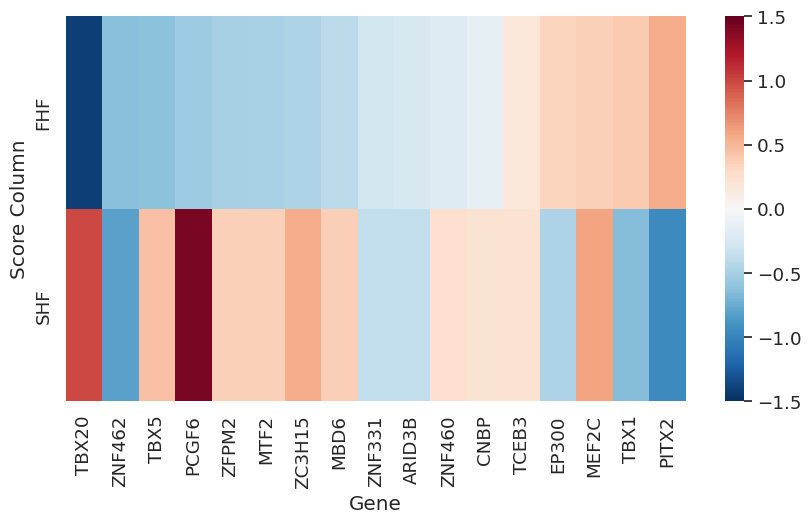

In [114]:
reg_df_stat_fhf_shf_cardiac_intact_plot = reg_df_stat_fhf_shf_cardiac_intact.sort_values("FHF").T
reg_df_stat_fhf_shf_cardiac_intact_plot.columns = \
    reg_df_stat_fhf_shf_cardiac_intact_plot.columns.map(lambda x:x.split(":")[0])

fig, ax = plt.subplots(figsize=(10,5))
sns.heatmap(reg_df_stat_fhf_shf_cardiac_intact_plot,
            cmap="RdBu_r",vmax=1.5,vmin=-1.5,ax=ax)
plt.savefig("../figure/FHF-SHF_map.pdf")

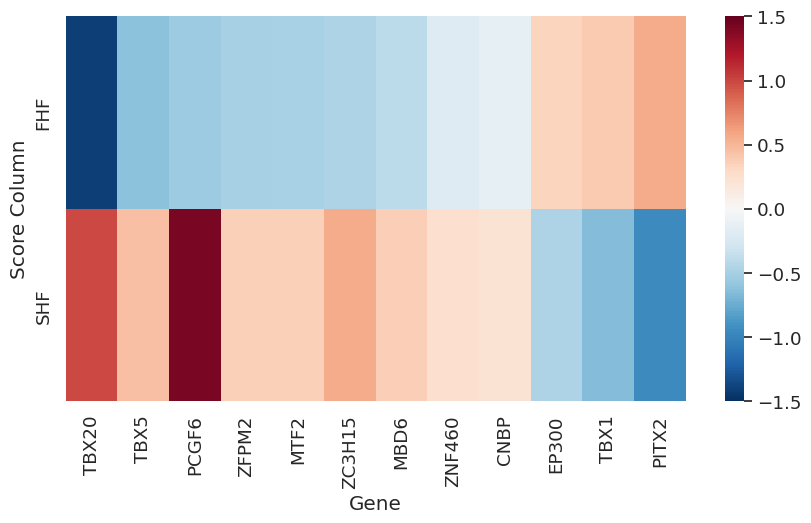

In [115]:
reg_df_stat_fhf_shf_rev_dir_plot = reg_df_stat_fhf_shf_rev_dir.sort_values("FHF").T
reg_df_stat_fhf_shf_rev_dir_plot.columns = \
    reg_df_stat_fhf_shf_rev_dir_plot.columns.map(lambda x:x.split(":")[0])

fig, ax = plt.subplots(figsize=(10,5))
sns.heatmap(reg_df_stat_fhf_shf_rev_dir_plot,
            cmap="RdBu_r",vmax=1.5,vmin=-1.5,ax=ax)
plt.savefig("../figure/FHF-SHF_map_rev_dir.pdf")

### Annotation of CS8 gene program

In [67]:
cell_type_gp_path_CS8 = "/project/GCRB/Hon_lab/s223695/Data_project/20250620_embryo_analysis/processed_data/cell_type_expression_CS8.csv"
cell_type_gp_df_CS8 = pd.read_csv(cell_type_gp_path_CS8,index_col=0)

In [68]:
z_df_CS8 = (cell_type_gp_df_CS8 - cell_type_gp_df_CS8.mean()) / cell_type_gp_df_CS8.std()
high_z_score_list_CS8 = z_df_CS8.apply(lambda x: x.index[np.argmax(x)],axis=1)

In [69]:
high_z_score_list_CS8

AM               25
AM EXM Meso      71
Endo             14
Epi/Ecto          8
Ery              16
Gast/PS          33
HEP              18
Meso              6
Noto             99
Visceral Endo    10
YS EXM meso-A     5
YS EXM meso-B     1
YS Endo           3
dtype: object

<Axes: >

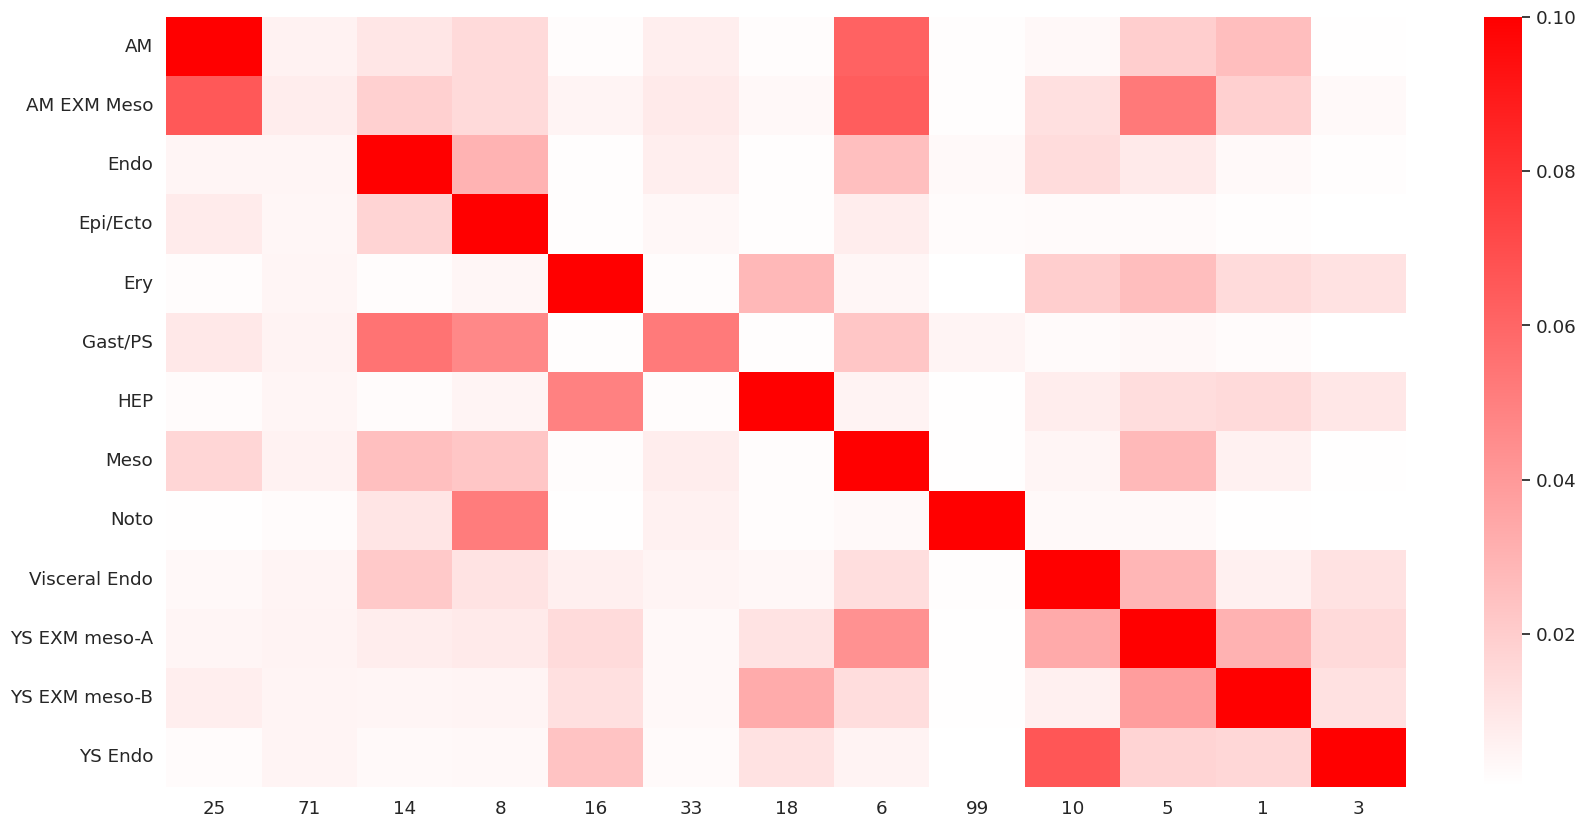

In [70]:
fig,ax=plt.subplots(figsize=(20,10))
cmap = sns.blend_palette(["white","red"], as_cmap=True)
sns.heatmap(cell_type_gp_df_CS8.loc[:,high_z_score_list_CS8.values],
            cmap=cmap,
            vmax=0.1)

In [71]:
top_similar_df_list_CS8 = []

for cell_type, gp_idx in high_z_score_list_CS8.items():
    gp_name = f"CS8_Usage{gp_idx}"
    for time_point in time_point_list:
        top_similar_gp_df = res_list_df[(res_list_df["Embryo_gp_name"]==gp_name) & \
                                        (res_list_df["Perturb_time_point"]==time_point)].sort_values("Num_overlap_gene",ascending=False).iloc[0]
        usage_idx = \
            top_similar_gp_df["Time_Course_gp_name"].split("_Usage")[1]
        gp_exp_mean = usage_df_dict[time_point].loc[:,usage_idx].mean()
        top_similar_df_list_CS8.append([cell_type,gp_name,top_similar_gp_df["Time_Course_gp_name"],time_point,
                                        top_similar_gp_df["Num_overlap_gene"],gp_exp_mean])

#Summarize
top_similar_df_CS8 = pd.DataFrame(top_similar_df_list_CS8,
                                  columns=["cell_type","gp_vivo","gp_vitro","time_point","num_overlap","mean_gp_exp"])

In [72]:
top_similar_df_CS8_pivot = \
    top_similar_df_CS8.pivot(index="cell_type",columns="time_point",values="num_overlap")

top_similar_df_CS8_pivot = top_similar_df_CS8_pivot.loc[:,time_point_list]

In [73]:
key_cell_type_CS8 = ["Epi/Ecto","Gast/PS","Meso","Endo"]
top_similar_df_CS8_pivot_select = top_similar_df_CS8_pivot.loc[key_cell_type_CS8]

In [74]:
top_similar_df_CS8.head()

,cell_type,gp_vivo,gp_vitro,time_point,num_overlap,mean_gp_exp
0,AM,CS8_Usage25,D4_Usage29,D4,14,0.012077
1,AM,CS8_Usage25,D8_Usage92,D8,25,0.001141
2,AM,CS8_Usage25,D12_Usage88,D12,28,0.001016
3,AM,CS8_Usage25,D29_Usage82,D29,15,0.000638
4,AM EXM Meso,CS8_Usage71,D4_Usage100,D4,3,0.000357


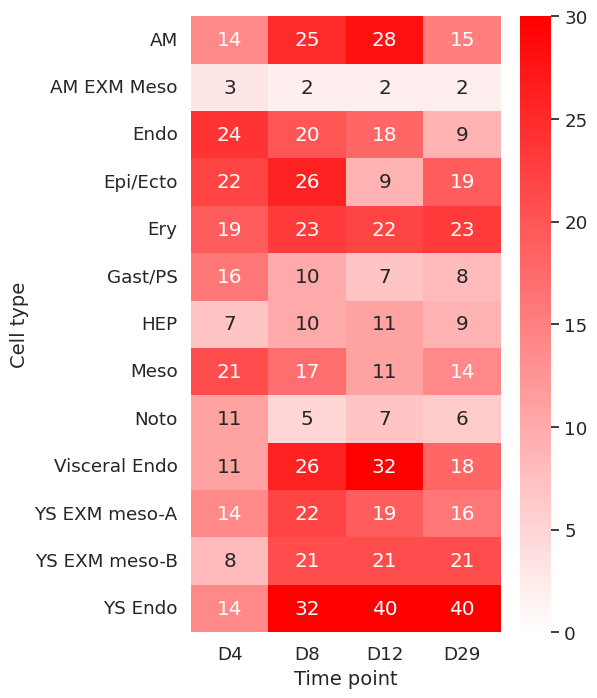

In [75]:
fig, ax = plt.subplots(figsize=(5, 8))
cmap = sns.blend_palette(["white","red"], as_cmap=True)

sns.heatmap(
    data=top_similar_df_CS8_pivot,
    cmap=cmap,
    vmax=30,vmin=0,
    annot=True,
    ax=ax
)

# Axis labels
ax.set_xlabel("Time point", fontsize=14)
ax.set_ylabel("Cell type", fontsize=14)
plt.savefig("../figure/CS8_alltimepoint_all.pdf")

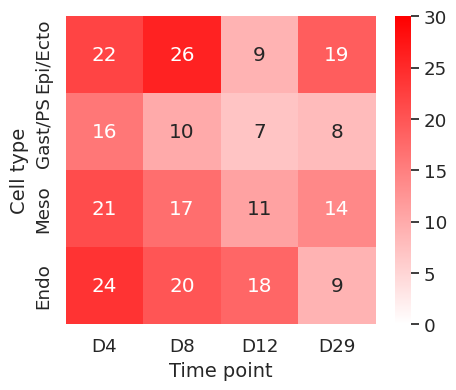

In [76]:
fig, ax = plt.subplots(figsize=(5, 4))
cmap = sns.blend_palette(["white","red"], as_cmap=True)
sns.heatmap(
    data=top_similar_df_CS8_pivot_select,
    vmax=30,vmin=0,
    cmap=cmap,
    annot=True,
    ax=ax
)

# Axis labels
ax.set_xlabel("Time point", fontsize=14)
ax.set_ylabel("Cell type", fontsize=14)
plt.savefig("../figure/CS8_alltimepoint_select.pdf")

### Annotation of CS9 gene program

In [77]:
cell_type_gp_path_CS9 = "/project/GCRB/Hon_lab/s223695/Data_project/20250620_embryo_analysis/processed_data/cell_type_expression_CS9.csv"
cell_type_gp_df_CS9 = pd.read_csv(cell_type_gp_path_CS9,index_col=0)

In [78]:
z_df_CS9 = (cell_type_gp_df_CS9 - cell_type_gp_df_CS9.mean()) / cell_type_gp_df_CS9.std()
high_z_score_list_CS9 = z_df_CS9.apply(lambda x: x.index[np.argmax(x)],axis=1)

In [79]:
z_df_CS9.sort_values("HBP",axis=1,ascending=False).loc[["FBP","MBP","HBP"],:]

,66,67,68,77,50,7,12,29,40,3,...,2,30,71,61,33,58,81,100,9,8
FBP,-0.168019,0.553580,0.025136,0.086842,0.499276,-0.502611,-0.331759,-0.034748,0.200983,-0.341819,...,-0.804925,-0.599371,-0.443748,-0.399452,-0.330349,-0.622894,-0.751497,0.388406,1.424308,0.137271
MBP,0.008817,0.379208,1.071347,-0.073100,4.327310,-0.965932,-0.294509,-0.071315,4.626370,-0.500236,...,-0.345330,-0.515135,-0.434004,-0.426878,-0.069860,-0.674926,-0.756723,-0.638117,-0.155837,0.883874
HBP,4.946113,4.809193,4.801188,3.172626,1.965054,1.839175,0.897087,0.759645,0.758206,0.746547,...,-0.566626,-0.618381,-0.622005,-0.641610,-0.647730,-0.707398,-0.822449,-0.847718,-0.936362,-1.258460


<Axes: >

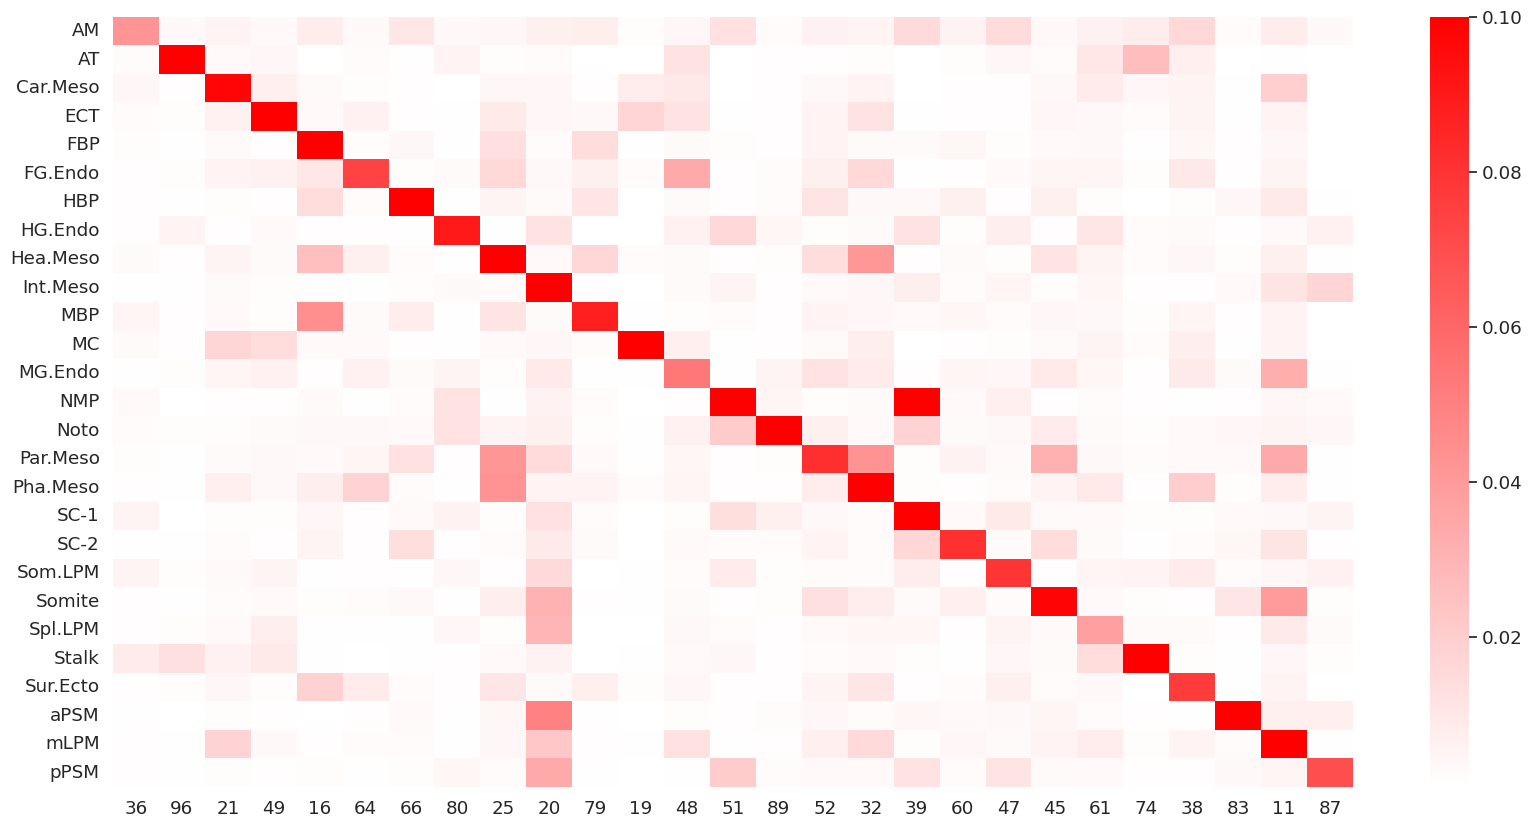

In [80]:
fig,ax=plt.subplots(figsize=(20,10))
cmap = sns.blend_palette(["white","red"], as_cmap=True)

sns.heatmap(cell_type_gp_df_CS9.loc[:,high_z_score_list_CS9.values],
            cmap=cmap,
            vmax=0.1)

In [81]:
top_similar_df_list_CS9 = []

for cell_type, gp_idx in high_z_score_list_CS9.items():
    gp_name = f"CS9embryo_Usage{gp_idx}"
    for time_point in time_point_list:
        top_similar_gp_df = res_list_df[(res_list_df["Embryo_gp_name"]==gp_name) & \
                                        (res_list_df["Perturb_time_point"]==time_point)].sort_values("Num_overlap_gene",ascending=False).iloc[0]
        usage_idx = \
            top_similar_gp_df["Time_Course_gp_name"].split("_Usage")[1]
        gp_exp_mean = usage_df_dict[time_point].loc[:,usage_idx].mean()
        top_similar_df_list_CS9.append([cell_type,gp_name,top_similar_gp_df["Time_Course_gp_name"],time_point,
                                        top_similar_gp_df["Num_overlap_gene"],gp_exp_mean])

#Summarize
top_similar_df_CS9 = pd.DataFrame(top_similar_df_list_CS9,
                                  columns=["cell_type","gp_vivo","gp_vitro","time_point","num_overlap","mean_gp_exp"])

In [82]:
top_similar_df_CS9_pivot = \
    top_similar_df_CS9.pivot(index="cell_type",columns="time_point",values="num_overlap")

top_similar_df_CS9_pivot = top_similar_df_CS9_pivot.loc[:,time_point_list]

In [83]:
key_cell_type_CS9 = ["ECT","MC","MG.Endo","Sur.Ecto"]
top_similar_df_CS9_pivot_select = top_similar_df_CS9_pivot.loc[key_cell_type_CS9]

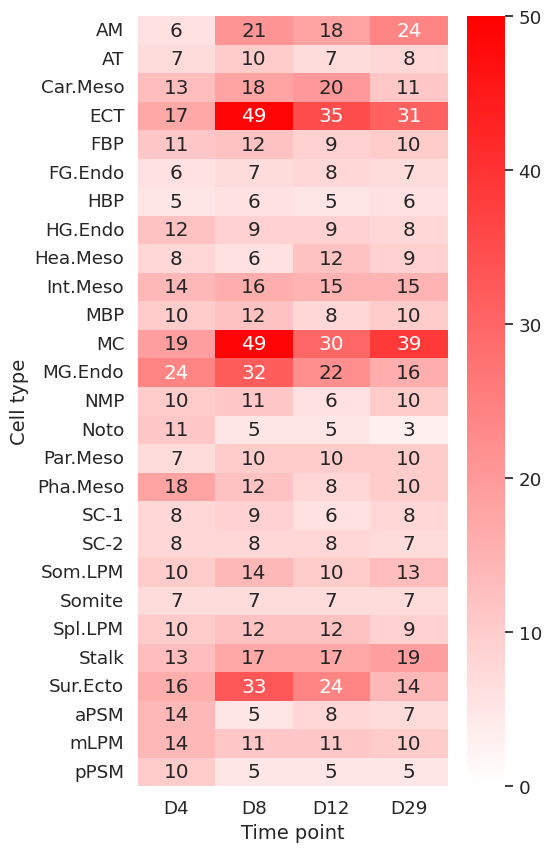

In [84]:
fig, ax = plt.subplots(figsize=(5, 10))
cmap = sns.blend_palette(["white","red"], as_cmap=True)
sns.heatmap(
    data=top_similar_df_CS9_pivot,
    vmax=50,vmin=0,
    cmap=cmap,
    annot=True,
    ax=ax
)

# Axis labels
ax.set_xlabel("Time point", fontsize=14)
ax.set_ylabel("Cell type", fontsize=14)
plt.savefig("../figure/CS9_alltimepoint_all.pdf")

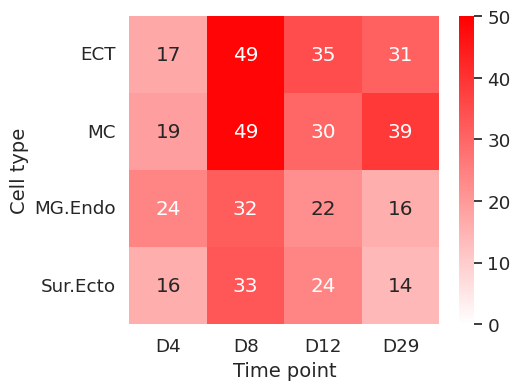

In [85]:
fig, ax = plt.subplots(figsize=(5, 4))
cmap = sns.blend_palette(["white","red"], as_cmap=True)
sns.heatmap(
    data=top_similar_df_CS9_pivot_select,
    vmax=50,vmin=0,
    cmap=cmap,
    annot=True,
    ax=ax
)

# Axis labels
ax.set_xlabel("Time point", fontsize=14)
ax.set_ylabel("Cell type", fontsize=14)
plt.savefig("../figure/CS9_alltimepoint_select.pdf")

### Assign cell type based on GP similarity

In [86]:
similar_gp_CS8 = top_similar_df_CS8[(top_similar_df_CS8["num_overlap"]>20) & \
                                    (top_similar_df_CS8["time_point"]=="D4")].copy()
similar_gp_CS8["vis_name"] = similar_gp_CS8.apply(lambda x:f"{x["gp_vitro"]} ({x["cell_type"]})",axis=1)

similar_gp_CS9 = top_similar_df_CS9[(top_similar_df_CS9["num_overlap"]>20) & \
                                    (top_similar_df_CS8["time_point"]=="D8")].copy()
similar_gp_CS9["vis_name"] = similar_gp_CS9.apply(lambda x:f"{x["gp_vitro"]} ({x["cell_type"]})",axis=1)

In [87]:
similar_gp_CS8

,cell_type,gp_vivo,gp_vitro,time_point,num_overlap,mean_gp_exp,vis_name
8,Endo,CS8_Usage14,D4_Usage54,D4,24,0.005843,D4_Usage54 (Endo)
12,Epi/Ecto,CS8_Usage8,D4_Usage67,D4,22,0.003871,D4_Usage67 (Epi/Ecto)
28,Meso,CS8_Usage6,D4_Usage73,D4,21,0.001795,D4_Usage73 (Meso)


In [88]:
similar_gp_CS9

,cell_type,gp_vivo,gp_vitro,time_point,num_overlap,mean_gp_exp,vis_name
1,AM,CS9embryo_Usage36,D8_Usage58,D8,21,0.005155,D8_Usage58 (AM)
13,ECT,CS9embryo_Usage49,D8_Usage74,D8,49,0.002970,D8_Usage74 (ECT)
45,MC,CS9embryo_Usage19,D8_Usage45,D8,49,0.007642,D8_Usage45 (MC)
49,MG.Endo,CS9embryo_Usage48,D8_Usage47,D8,32,0.006685,D8_Usage47 (MG.Endo)


In [89]:
similar_gp_CS8_name_dict = {'D4_Usage54': 'D4_Usage54 (Endo)',
                            'D4_Usage67': 'D4_Usage67 (Epi/Ecto)'}

In [90]:
similar_gp_CS9_name_dict = {'D8_Usage58': 'D8_Usage58 (AM)',
                            'D8_Usage45': 'D8_Usage45 (MC)',
                            'D8_Usage47': 'D8_Usage47 (MG.Endo)'}

In [91]:
similar_gp_CS8.set_index("gp_vitro")

,cell_type,gp_vivo,time_point,num_overlap,mean_gp_exp,vis_name
gp_vitro,,,,,,
D4_Usage54,Endo,CS8_Usage14,D4,24,0.005843,D4_Usage54 (Endo)
D4_Usage67,Epi/Ecto,CS8_Usage8,D4,22,0.003871,D4_Usage67 (Epi/Ecto)
D4_Usage73,Meso,CS8_Usage6,D4,21,0.001795,D4_Usage73 (Meso)


In [92]:
reg_df_stat_log2fc_CS8 = regulation_df_dict_total_merge[
                            (regulation_df_dict_total_merge["Score Column"].apply(
                                lambda x: x in similar_gp_CS8_name_dict.keys()))
                        ].pivot(columns="Score Column",values="Log2 Fold Change",index="Gene")

reg_df_stat_fdr_CS8 = regulation_df_dict_total_merge[
                            (regulation_df_dict_total_merge["Score Column"].apply(
                                lambda x: x in similar_gp_CS8_name_dict.keys()))
                        ].pivot(columns="Score Column",values="Corrected p-value (BH)",index="Gene")

reg_df_stat_log2fc_CS9 = regulation_df_dict_total_merge[
                            (regulation_df_dict_total_merge["Score Column"].apply(
                                lambda x: x in similar_gp_CS9_name_dict.keys()))
                        ].pivot(columns="Score Column",values="Log2 Fold Change",index="Gene")

reg_df_stat_fdr_CS9 = regulation_df_dict_total_merge[
                            (regulation_df_dict_total_merge["Score Column"].apply(
                                lambda x: x in similar_gp_CS9_name_dict.keys()))
                        ].pivot(columns="Score Column",values="Corrected p-value (BH)",index="Gene")

In [93]:
reg_df_stat_log2fc_CS9

Score Column,D8_Usage45,D8_Usage47,D8_Usage58
Gene,,,
ADNP2:P1P2,-0.204284,-0.580367,0.483615
AFF4:P1P2,-0.436703,0.214644,0.314263
AHCY:P1P2,-0.096744,0.055640,0.073000
AHDC1:P1P2,-0.105475,-0.051930,-0.053368
APITD1:P1P2,-0.154337,0.319599,-0.264055
...,...,...,...
ZNF91:P1P2,0.037323,0.217536,-0.188104
ZSCAN10:P1P2,-0.327948,-0.995453,0.159246
ZSCAN20:P1P2,-0.221697,0.225945,-0.043392


In [94]:
fdr_cutoff = 0.05
reg_df_stat_log2fc_CS8_sig = reg_df_stat_log2fc_CS8[reg_df_stat_fdr_CS8<fdr_cutoff]
reg_df_stat_log2fc_CS8_sig = reg_df_stat_log2fc_CS8_sig.dropna(axis=0,how="all").fillna(0)
reg_df_stat_log2fc_CS8_sig.columns = \
    reg_df_stat_log2fc_CS8_sig.columns.map(similar_gp_CS8_name_dict)

reg_df_stat_log2fc_CS9_sig = reg_df_stat_log2fc_CS9[reg_df_stat_fdr_CS9<fdr_cutoff]
reg_df_stat_log2fc_CS9_sig = reg_df_stat_log2fc_CS9_sig.dropna(axis=0,how="all").fillna(0)
reg_df_stat_log2fc_CS9_sig.columns = \
    reg_df_stat_log2fc_CS9_sig.columns.map(similar_gp_CS9_name_dict)

In [95]:
reg_df_stat_log2fc_CS9_sig

Score Column,D8_Usage45 (MC),D8_Usage47 (MG.Endo),D8_Usage58 (AM)
Gene,,,
ADNP2:P1P2,0.000000,-0.580367,0.483615
AFF4:P1P2,-0.436703,0.000000,0.000000
APITD1:P1P2,0.000000,0.319599,0.000000
ARID1A:P1P2,-1.108248,1.077029,0.000000
ARID1B:P1,0.000000,0.589421,0.000000
...,...,...,...
ZNF532:P2,0.395161,0.474135,0.000000
ZNF598:P1P2,0.295887,0.000000,0.000000
ZNF608:P1,-1.035841,0.826607,-1.029044


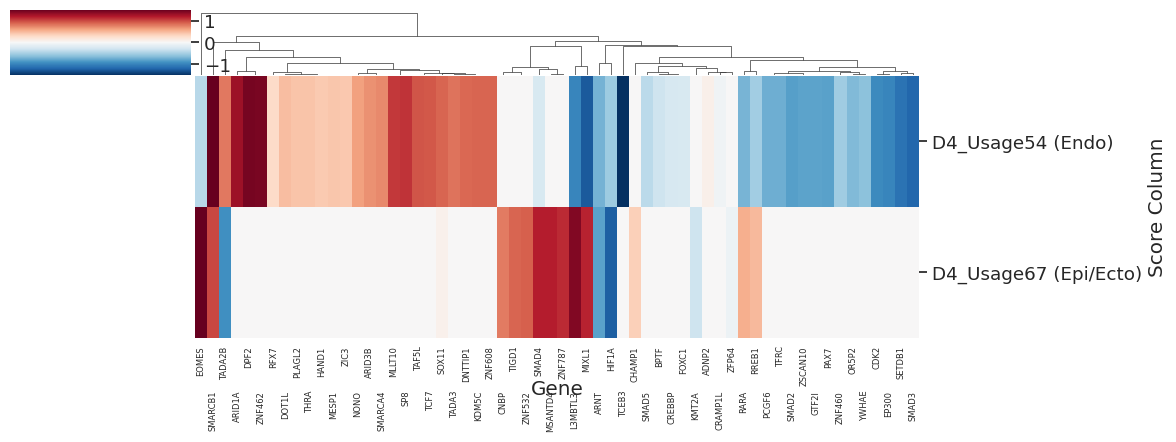

In [96]:
g = sns.clustermap(reg_df_stat_log2fc_CS8_sig.T,cmap="RdBu_r",row_cluster=False,
               vmax=1.5,vmin=-1.5,figsize=(12,5))
ax = g.ax_heatmap

# Use all labels in clustered order
labels = g.data2d.columns
xpos = np.arange(len(labels)) + 0.5

# Remove default tick labels
ax.set_xticks([])
ax.tick_params(axis="x", length=0)

# Draw all labels manually in two rows
for i, (x, lab) in enumerate(zip(xpos, labels)):
    lab = lab.split(":")[0]
    y = -0.03 if i % 2 == 0 else -0.20
    ax.text(
        x, y, lab,
        rotation=90,
        ha="center",
        va="top",
        fontsize=6,
        transform=ax.get_xaxis_transform(),
        clip_on=False
    )

ax.set_xlabel("Gene", labelpad=30)
g.fig.subplots_adjust(bottom=0.30)

g.savefig("../figure/clustermap_CS8_gp.pdf", dpi=300)

In [97]:
reg_df_stat_log2fc_CS8_sig.to_csv("../processed_data/gp_regulation_CS8.csv")

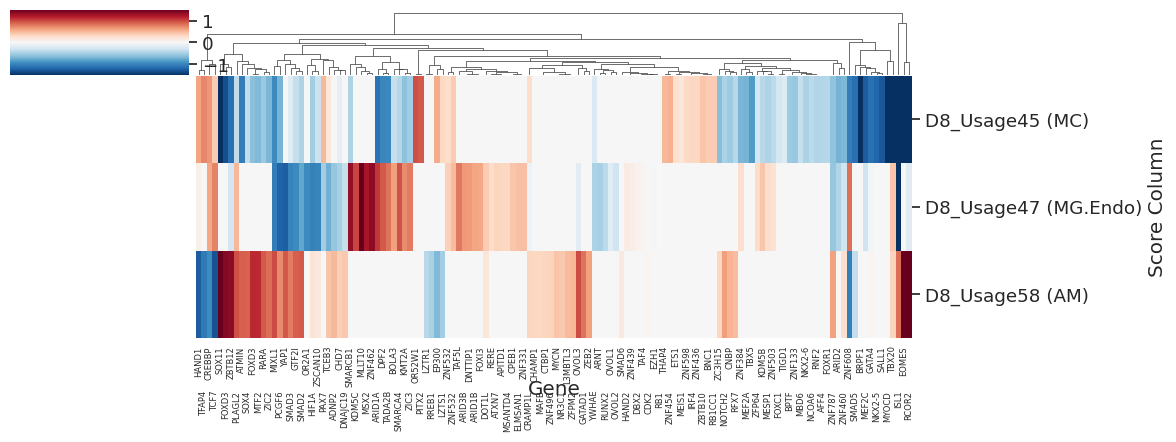

In [98]:
g = sns.clustermap(
    reg_df_stat_log2fc_CS9_sig.T,
    cmap="RdBu_r",
    row_cluster=False,
    vmax=1.5,
    vmin=-1.5,
    figsize=(12, 5)
)

ax = g.ax_heatmap

# Use all labels in clustered order
labels = g.data2d.columns
xpos = np.arange(len(labels)) + 0.5

# Remove default tick labels
ax.set_xticks([])
ax.tick_params(axis="x", length=0)

# Draw all labels manually in two rows
for i, (x, lab) in enumerate(zip(xpos, labels)):
    lab = lab.split(":")[0]
    y = -0.03 if i % 2 == 0 else -0.20
    ax.text(
        x, y, lab,
        rotation=90,
        ha="center",
        va="top",
        fontsize=6,
        transform=ax.get_xaxis_transform(),
        clip_on=False
    )

ax.set_xlabel("Gene", labelpad=30)
g.fig.subplots_adjust(bottom=0.30)


g.savefig("../figure/clustermap_CS9_gp.pdf", dpi=300)

In [99]:
reg_df_stat_log2fc_CS9_sig.to_csv("../processed_data/gp_regulation_CS9.csv")

#### Marker genes

In [100]:
marker_genes_dict = {
    "CM":["MYL7","TNNT2"],
    "Endoderm":["APELA","FOXA2"],
    "AM":["LUM","DCN"]
}

In [101]:
res_list = []
for gp_name in similar_gp_CS9_name_dict.keys():
    for cell_type, marker_genes in marker_genes_dict.items():
        for cell_type_gene in marker_genes:
            if cell_type_gene in top_gene_dict[gp_name]:
                gene_rank = np.where(top_gene_dict[gp_name]==cell_type_gene)[0][0]+1
            else:
                gene_rank = np.nan
            res_list.append([gp_name,cell_type,cell_type_gene,gene_rank])

marker_gene_df = pd.DataFrame(res_list,columns=["GP_name","cell_type","Marker_gene","rank"])

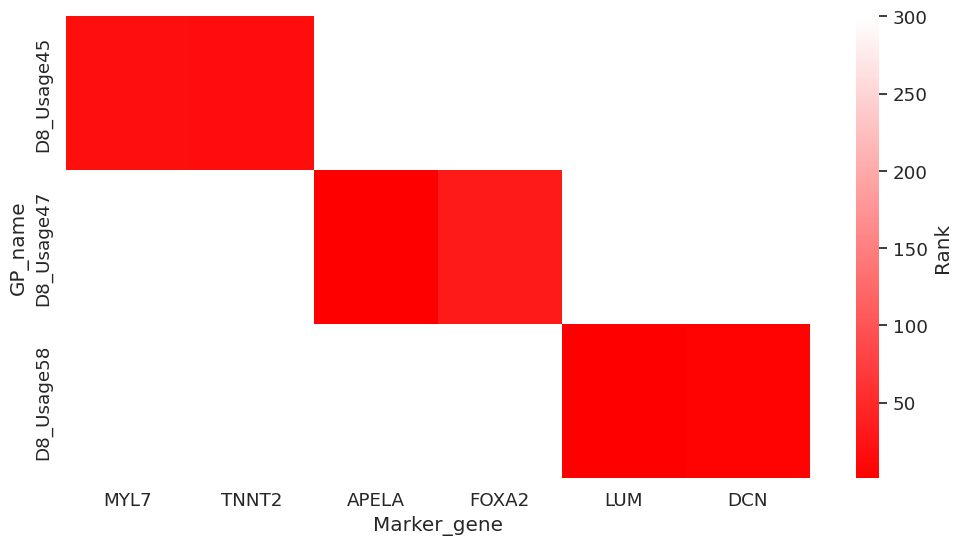

In [102]:
marker_gene_df_pivot = marker_gene_df.pivot(index="GP_name",columns="Marker_gene",values="rank")
marker_gene_df_pivot = marker_gene_df_pivot.fillna(300)

col_name = np.concatenate(list(marker_genes_dict.values()))
row_name = ["D8_Usage45","D8_Usage47","D8_Usage58"]
marker_gene_df_pivot = marker_gene_df_pivot.loc[row_name,col_name]

cmap = sns.blend_palette(["red","white"], as_cmap=True)

sns.set_theme(style="white", font_scale=1.2)

plt.figure(figsize=(12, 6))
ax = sns.heatmap(
    marker_gene_df_pivot,
    cmap=cmap,
    vmin=1,
    vmax=300,
    linewidths=0.0,
    linecolor="white",
    cbar_kws={"label": "Rank"}
)

plt.savefig("../figure/gene_marker_early_celltype.pdf")

#### Extract info

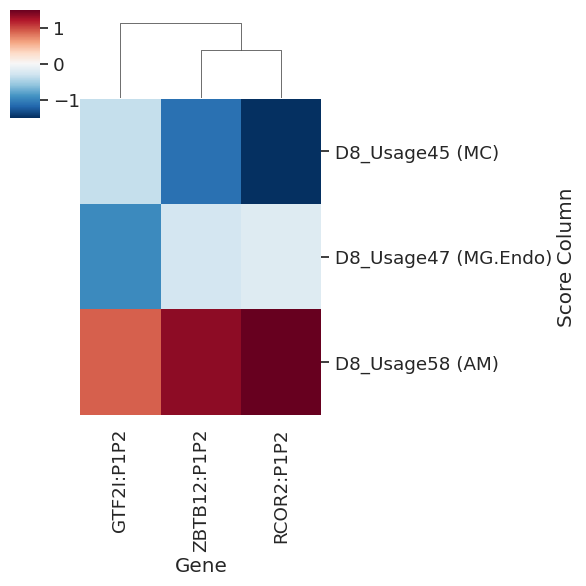

In [103]:
target_list = ["ZBTB12:P1P2","GTF2I:P1P2","RCOR2:P1P2"]

g = sns.clustermap(reg_df_stat_log2fc_CS9_sig.loc[target_list,:].T,cmap="RdBu_r",row_cluster=False,
               vmax=1.5,vmin=-1.5,figsize=(6,6))
g.savefig("../figure/clustermap_CS9_gp_selected.pdf", dpi=300)